# Taller 02 — Transfer Learning y Modelos Pre-entrenados en Diagnóstico Dermatológico

Curso **Aprendizaje Profundo · 32310019 · 2026-01** · Semilla global `SEED=161105`.

Este notebook resuelve el Taller 02 sobre **DermaMNIST (7 clases, 28×28 RGB)** integrando:

- comparación empírica **bilinear vs. bicubic** para el upsampling 28×28 → 224×224,
- evidencia de **domain shift** (ImageNet → dermatoscopia),
- **transfer learning** con MobileNetV2 en dos fases (Feature Extraction y Fine-Tuning),
- enfoque híbrido opcional **CNN features + Random Forest**,
- comparación contra una **arquitectura basada en atención** (DeiT / ViT compacto),
- evaluación multimodelo con énfasis en **recall de melanoma (`mel`, idx 5)**,
- exportación del mejor modelo y generación dinámica de `predict.py`.

Toda la lógica reutilizable vive en el paquete `src/`; este notebook orquesta el pipeline y produce las figuras del informe.

## 0. Instalación de dependencias

Versiones fijadas en `requirements.txt`. Ejecutar **una sola vez** en entorno limpio (Colab o venv recién creado); en un entorno ya configurado esta celda puede omitirse.

## 1. Imports y reproducibilidad

Imports de stdlib + stack científico + TensorFlow/Keras. El paquete `src/` se importará de forma incremental en las secciones siguientes; aquí sólo cargamos `SEED` para fijar la reproducibilidad global desde la primera celda.

**Fix BUG-01:** `HAS_KERAS_HUB` se define con `try/except ImportError` y se usa en la Sección 12 (DeiT/ViT) para decidir entre la ruta pre-entrenada y el fallback compacto.

In [1]:
# --- Standard library ---
import os
import json
import time
import random
import warnings
from pathlib import Path
from datetime import datetime, timezone

# --- Scientific stack ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- sklearn / joblib (usados directamente en Sección 11 — Híbrido CNN+RF) ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow import keras
# --- keras_hub es OPCIONAL: si está disponible intentaremos cargar DeiT
#     pre-entrenado; si no, la Sección 12 cae al ViT-compacto desde cero.
#     (FIX BUG-01 — antes la variable nunca se definía y la Sec. 12 crasheaba.)
try:
    import keras_hub  # noqa: F401
    HAS_KERAS_HUB = True
except ImportError:
    HAS_KERAS_HUB = False

# --- Única constante necesaria aquí: SEED (resto de config en Sección 2) ---
from src.config import SEED

# --- Reproducibilidad global ---
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Estética y silenciado de warnings ruidosos ---
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(context="notebook", style="whitegrid")
%matplotlib inline

# --- Diagnóstico del entorno ---
_gpus = tf.config.list_physical_devices("GPU")
print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
print(f"keras_hub  : {'disponible' if HAS_KERAS_HUB else 'NO disponible (se usará ViT fallback)'}")
print(f"GPU        : {len(_gpus)} dispositivo(s) detectado(s)" + (f' → {_gpus[0].name}' if _gpus else ''))
print(f"SEED       : {SEED}")

c:\GITHUB_REPOSITORIES_LOCAL\MACC_Aprendizaje_Profundo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow : 2.21.0
Keras      : 3.14.1
keras_hub  : disponible
GPU        : 0 dispositivo(s) detectado(s)
SEED       : 161105


## 2. Configuración

Toda la configuración vive centralizada en `src/config.py`. Aquí la importamos y mostramos un resumen para que quede explícita en el notebook qué constantes están activas (especialmente `FAST_MODE`, que controla épocas y tamaños de subset).

- `FAST_MODE=True` → épocas reducidas + `stratified_subset()` sobre train/val/test (~1400 / 250 / 500). Útil para iterar.
- `FAST_MODE=False` → entrega final, dataset completo.

Las carpetas `artifacts_taller_02/` y `figures/` se crean si no existen.

In [2]:
# Importa toda la configuración desde el paquete src/.
# El notebook NO redefine constantes: si algo cambia, se cambia en src/config.py.
from src.config import (
    # Generales
    DATA_FLAG, SOURCE_SIZE, TARGET_SIZE, NUM_CLASSES, BATCH_SIZE,
    FAST_MODE,
    # Épocas por modelo
    EPOCHS_BASELINE, EPOCHS_MOBILENET_FE, EPOCHS_MOBILENET_FT, EPOCHS_VIT,
    # Learning rates por fase
    LR_BASELINE, LR_FE, LR_FT, LR_VIT,
    # Subsets en FAST_MODE
    MAX_TRAIN_FAST, MAX_VAL_FAST, MAX_TEST_FAST,
    # Rutas y flags de pipeline
    EXPORT_DIR, FIGURES_DIR, RUN_HYBRID_RF, RUN_DEIT,
)

# Garantiza que existan las carpetas de salida (idempotente).
EXPORT_DIR = Path(EXPORT_DIR)
FIGURES_DIR = Path(FIGURES_DIR)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Resumen legible — sirve de bitácora si exportamos el notebook ejecutado.
config_summary = {
    "SEED": SEED,
    "DATA_FLAG": DATA_FLAG,
    "SOURCE_SIZE": SOURCE_SIZE,
    "TARGET_SIZE": TARGET_SIZE,
    "NUM_CLASSES": NUM_CLASSES,
    "BATCH_SIZE": BATCH_SIZE,
    "FAST_MODE": FAST_MODE,
    "epochs": {
        "baseline": EPOCHS_BASELINE,
        "mobilenet_fe": EPOCHS_MOBILENET_FE,
        "mobilenet_ft": EPOCHS_MOBILENET_FT,
        "vit": EPOCHS_VIT,
    },
    "learning_rates": {
        "baseline": LR_BASELINE,
        "fe": LR_FE,
        "ft": LR_FT,
        "vit": LR_VIT,
    },
    "fast_subset_caps": {
        "train": MAX_TRAIN_FAST,
        "val": MAX_VAL_FAST,
        "test": MAX_TEST_FAST,
    },
    "flags": {
        "RUN_HYBRID_RF": RUN_HYBRID_RF,
        "RUN_DEIT": RUN_DEIT,
        "HAS_KERAS_HUB": HAS_KERAS_HUB,
    },
    "paths": {
        "EXPORT_DIR": str(EXPORT_DIR.resolve()),
        "FIGURES_DIR": str(FIGURES_DIR.resolve()),
    },
}

print(json.dumps(config_summary, indent=2, ensure_ascii=False))

{
  "SEED": 161105,
  "DATA_FLAG": "dermamnist",
  "SOURCE_SIZE": 28,
  "TARGET_SIZE": 224,
  "NUM_CLASSES": 7,
  "BATCH_SIZE": 32,
  "FAST_MODE": true,
  "epochs": {
    "baseline": 10,
    "mobilenet_fe": 5,
    "mobilenet_ft": 5,
    "vit": 4
  },
  "learning_rates": {
    "baseline": 0.001,
    "fe": 0.001,
    "ft": 1e-05,
    "vit": 5e-05
  },
  "fast_subset_caps": {
    "train": 1400,
    "val": 250,
    "test": 500
  },
  "flags": {
    "RUN_HYBRID_RF": true,
    "RUN_DEIT": true,
    "HAS_KERAS_HUB": true
  },
  "paths": {
    "EXPORT_DIR": "C:\\GITHUB_REPOSITORIES_LOCAL\\MACC_Aprendizaje_Profundo\\Taller_02\\artifacts_taller_02",
    "FIGURES_DIR": "C:\\GITHUB_REPOSITORIES_LOCAL\\MACC_Aprendizaje_Profundo\\Taller_02\\figures"
  }
}


## 3. Carga de datos y EDA

Carga `DermaMNIST` 28×28 RGB vía `src.data_loader.load_dermamnist()`, que devuelve los tres splits junto con `class_names` y `mel_idx` (índice de la clase crítica **melanoma**).

Cuando `FAST_MODE=True`, aplicamos `stratified_subset()` sobre cada split para iterar rápido manteniendo la proporción original de clases — esto es importante porque el dataset tiene un fuerte desbalance dominado por `nv`.

**EDA visual:**
- Distribución de clases en los tres splits (figura `class_distribution.png`).
- 5 muestras por clase del set de entrenamiento (figura `samples_per_class.png`).

In [3]:
from src.data_loader import load_dermamnist, stratified_subset
from src.visualization import plot_class_distribution, show_samples_per_class

# --- Carga cruda del dataset (28x28 RGB, 7 clases) ---
x_train, y_train, x_val, y_val, x_test, y_test, class_names, mel_idx = load_dermamnist()

print("=== Tamaños originales ===")
print(f"  train : {x_train.shape}  labels: {y_train.shape}")
print(f"  val   : {x_val.shape}    labels: {y_val.shape}")
print(f"  test  : {x_test.shape}   labels: {y_test.shape}")
print(f"  clases: {class_names}")
print(f"  mel_idx (clase crítica): {mel_idx}  →  '{class_names[mel_idx]}'")

# --- Subsets estratificados SOLO en FAST_MODE ---
if FAST_MODE:
    x_train, y_train = stratified_subset(x_train, y_train, MAX_TRAIN_FAST, seed=SEED)
    x_val,   y_val   = stratified_subset(x_val,   y_val,   MAX_VAL_FAST,   seed=SEED)
    x_test,  y_test  = stratified_subset(x_test,  y_test,  MAX_TEST_FAST,  seed=SEED)
    print("\n=== Tamaños tras stratified_subset (FAST_MODE) ===")
    print(f"  train : {x_train.shape}")
    print(f"  val   : {x_val.shape}")
    print(f"  test  : {x_test.shape}")

=== Tamaños originales ===
  train : (7007, 28, 28, 3)  labels: (7007,)
  val   : (1003, 28, 28, 3)    labels: (1003,)
  test  : (2005, 28, 28, 3)   labels: (2005,)
  clases: ['actinic keratoses and intraepithelial carcinoma', 'basal cell carcinoma', 'benign keratosis-like lesions', 'dermatofibroma', 'melanoma', 'melanocytic nevi', 'vascular lesions']
  mel_idx (clase crítica): 4  →  'melanoma'

=== Tamaños tras stratified_subset (FAST_MODE) ===
  train : (1400, 28, 28, 3)
  val   : (250, 28, 28, 3)
  test  : (500, 28, 28, 3)


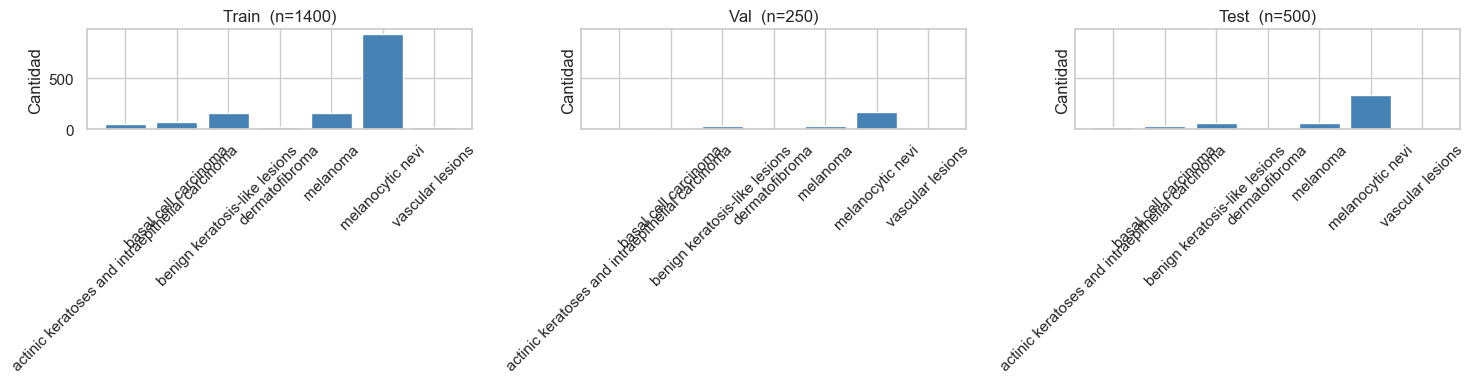


=== Conteos por clase y split ===
                                                 train  val  test  % train
actinic keratoses and intraepithelial carcinoma     45    8    16     3.21
basal cell carcinoma                                72   13    26     5.14
benign keratosis-like lesions                      154   27    55    11.00
dermatofibroma                                      16    3     6     1.14
melanoma                                           155   28    56    11.07
melanocytic nevi                                   938  167   334    67.00
vascular lesions                                    20    4     7     1.43
total                                             1400  250   500   100.00

Clase mayoritaria en train : 'melanocytic nevi'
Clase crítica (melanoma)   : 'melanoma'  → 155 muestras (11.07% del train)


In [4]:
# --- Distribución de clases en los 3 splits ---
plot_class_distribution(
    y_train, y_val, y_test,
    class_names=class_names,
    save_path=FIGURES_DIR / "class_distribution.png",
)

# --- Tabla numérica con proporciones (útil para discutir desbalance en el informe) ---
def _split_counts(y, name):
    counts = np.bincount(y, minlength=NUM_CLASSES)
    return pd.Series(counts, index=class_names, name=name)

dist_df = pd.concat(
    [_split_counts(y_train, "train"),
     _split_counts(y_val,   "val"),
     _split_counts(y_test,  "test")],
    axis=1,
)
dist_df.loc["total"] = dist_df.sum(axis=0)
dist_df["% train"] = (dist_df["train"] / dist_df.loc["total", "train"] * 100).round(2)

print("\n=== Conteos por clase y split ===")
print(dist_df)
print(f"\nClase mayoritaria en train : '{class_names[int(np.bincount(y_train).argmax())]}'")
print(f"Clase crítica (melanoma)   : '{class_names[mel_idx]}'  "
      f"→ {(y_train == mel_idx).sum()} muestras ({(y_train == mel_idx).mean()*100:.2f}% del train)")

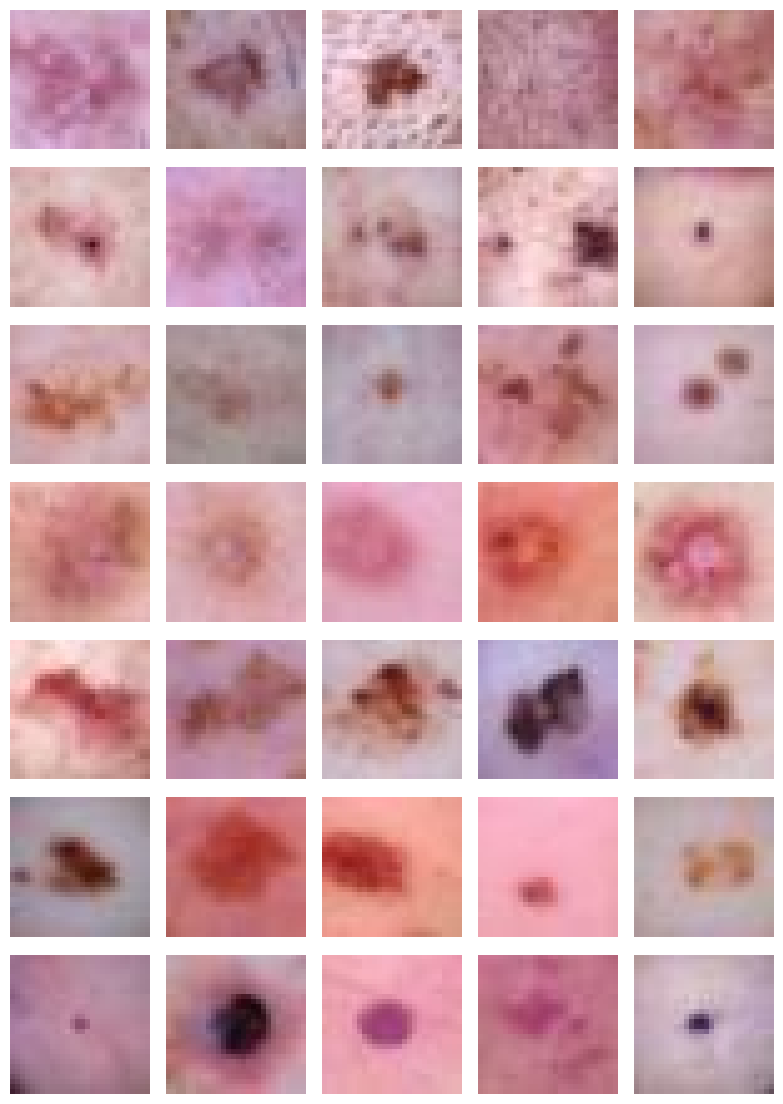

In [5]:
# --- Muestras por clase (5 por clase del set de entrenamiento) ---
show_samples_per_class(
    x_train, y_train,
    class_names=class_names,
    n_per_class=5,
    save_path=FIGURES_DIR / "samples_per_class.png",
)

## 4. Comparación de interpolación: bilinear vs. bicubic

El taller pide subir de 28×28 a 224×224 antes de alimentar modelos pre-entrenados de ImageNet. Esa decisión no es neutra:

- **Bilinear** es un kernel separable de soporte 2 → suaviza, atenúa altas frecuencias, *under-shoot* en bordes finos.
- **Bicubic** es un kernel separable de soporte 4 → preserva mejor la nitidez aparente, pero introduce **ringing / over-shoot** cerca de bordes fuertes (Gibbs).

Evaluamos cuatro evidencias para escoger una de las dos:

1. **`roundtrip_mse`**: error de ida y vuelta 28→224→28 (con `tf.image.resize(method="area")` en la bajada). Penaliza la interpolación que pierde información reconstruible.
2. **`gradient_energy`**: energía de gradientes ‖∇I‖² del *upsample*. Detecta tanto exceso de suavizado (bajo) como artefactos de overshoot (artificialmente alto).
3. **Side-by-side cualitativo** sobre una lesión `mel` real.
4. **Espectro radial promedio (FFT)** sobre un sub-batch: cuantifica la diferencia espectral entre métodos en el dominio frecuencial (cubre P4 del enunciado: análisis cuantitativo de frecuencias).

Criterio de selección: mínimo `roundtrip_mse` con `gradient_energy` razonable (sin overshoot extremo). El resultado se guarda en `SELECTED_INTERPOLATION` y se usa en todas las familias 224×224 posteriores.

In [6]:
from src.visualization import plot_interpolation_comparison

INTERPOLATIONS = ["bilinear", "bicubic"]

def resize_np(images, size, method="bilinear"):
    """Wrapper sobre tf.image.resize que acepta y devuelve numpy float32."""
    t = tf.convert_to_tensor(images, dtype=tf.float32)
    return tf.image.resize(t, (size, size), method=method).numpy()

def gradient_energy(images):
    """Energía media de gradientes ‖∇I‖² en el espacio de píxeles."""
    gx = np.diff(images, axis=2)
    gy = np.diff(images, axis=1)
    return float(np.mean(gx**2) + np.mean(gy**2))

def roundtrip_metrics(images, method, target_size=TARGET_SIZE, source_size=SOURCE_SIZE):
    """Métricas empíricas para un método de interpolación dado."""
    up   = resize_np(images, target_size, method=method)
    down = resize_np(up,     source_size, method="area")  # antialiased downsample
    return {
        "interpolation":        method,
        "roundtrip_mse":        float(np.mean((images.astype("float32") - down)**2)),
        "gradient_energy_up":   gradient_energy(up),
        "gradient_energy_down": gradient_energy(down),
    }

def radial_spectrum(image_batch):
    """Espectro radial promedio (magnitud log) sobre el canal de luminancia.
       image_batch: [N, H, W, 3] float32. Devuelve vector de longitud H//2."""
    lum = (0.2126*image_batch[..., 0] + 0.7152*image_batch[..., 1] + 0.0722*image_batch[..., 2])
    F   = np.fft.fftshift(np.fft.fft2(lum, axes=(-2, -1)), axes=(-2, -1))
    mag = np.log1p(np.abs(F))                       # log-magnitud, estabiliza media
    H, W = mag.shape[-2:]
    cy, cx = H // 2, W // 2
    y, x = np.indices((H, W))
    r = np.sqrt((y - cy)**2 + (x - cx)**2).astype(np.int32)
    r_max = min(cy, cx)
    # Promedio por anillo radial y luego promedio sobre el batch
    radial = np.zeros((mag.shape[0], r_max), dtype=np.float64)
    for k in range(r_max):
        mask = (r == k)
        radial[:, k] = mag[..., mask].mean(axis=-1)
    return radial.mean(axis=0), r_max

In [7]:
# --- Métricas sobre un sub-batch estratificado por reproducibilidad ---
sample_n = min(256, len(x_train))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(x_train), size=sample_n, replace=False)
interp_sample = x_train[sample_idx].astype("float32")

interp_metrics_df = (
    pd.DataFrame([roundtrip_metrics(interp_sample, method=m) for m in INTERPOLATIONS])
      .sort_values("roundtrip_mse")
      .reset_index(drop=True)
)

print("=== Métricas empíricas de interpolación (sample_n =", sample_n, ") ===")
print(interp_metrics_df.to_string(index=False))

=== Métricas empíricas de interpolación (sample_n = 256 ) ===
interpolation  roundtrip_mse  gradient_energy_up  gradient_energy_down
      bicubic       0.702349            2.515262            140.790894
     bilinear       2.358711            2.253906            125.580124


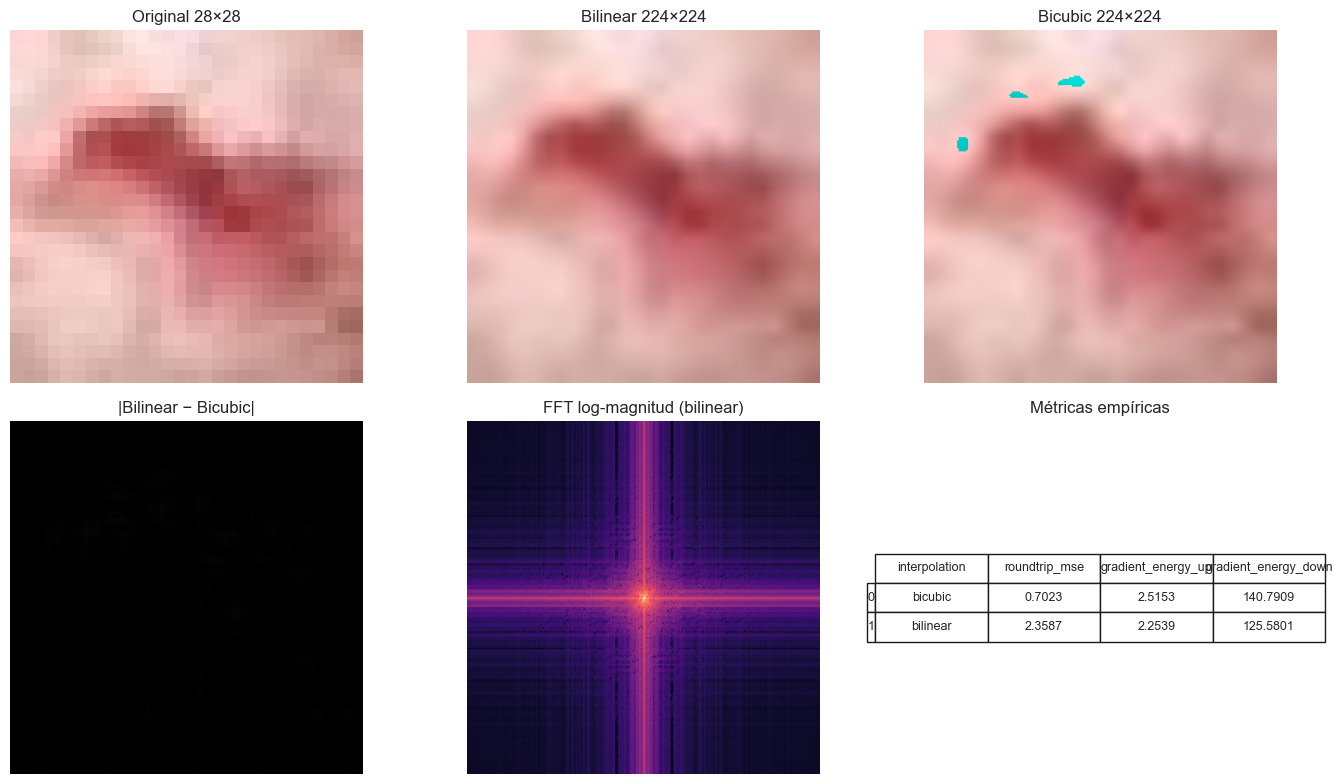

Ejemplo visualizado: idx=13, clase='melanoma'


In [10]:
# --- Side-by-side cualitativo sobre una lesión 'mel' real (clase crítica) ---
mel_positions = np.where(y_train == mel_idx)[0]
example_idx   = int(mel_positions[0]) if mel_positions.size > 0 else 0
example_img   = x_train[example_idx].astype("float32")

img_bilinear = resize_np(example_img[None, ...], TARGET_SIZE, "bilinear")[0]
img_bicubic  = resize_np(example_img[None, ...], TARGET_SIZE, "bicubic" )[0]

plot_interpolation_comparison(
    img_original=example_img,
    img_bilinear=img_bilinear,
    img_bicubic=img_bicubic,
    interp_metrics_df=interp_metrics_df,
    save_path=FIGURES_DIR / "interp_comparison.png",
)

print(f"Ejemplo visualizado: idx={example_idx}, clase='{class_names[int(y_train[example_idx])]}'")

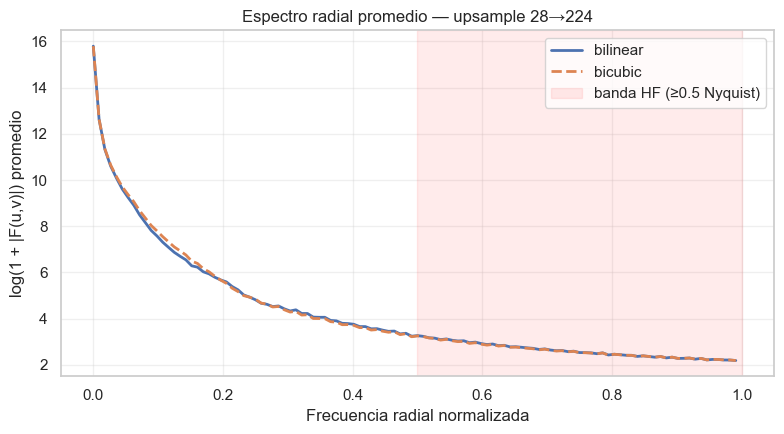

Energía HF media (≥0.5 Nyquist):
  bilinear : 2.6176
  bicubic  : 2.6086   (-0.3% vs bilinear)


In [11]:
# --- Análisis cuantitativo en el dominio frecuencial (P4) ---
# Se compara el espectro radial promedio del upsample bilinear vs bicubic.
# La diferencia indica qué método preserva más componentes de alta frecuencia
# y, leída junto con gradient_energy_up, ayuda a discriminar 'detalle real'
# vs 'ringing' (overshoot localizado de bicubic).
fft_sample = interp_sample[: min(64, sample_n)]

up_bilinear = resize_np(fft_sample, TARGET_SIZE, "bilinear")
up_bicubic  = resize_np(fft_sample, TARGET_SIZE, "bicubic" )

rad_bil, r_max = radial_spectrum(up_bilinear)
rad_bic, _     = radial_spectrum(up_bicubic)

freqs = np.arange(r_max) / r_max  # frecuencia normalizada [0, 1]
hf_mask = freqs >= 0.5            # mitad superior del espectro = alta frecuencia
hf_energy_bilinear = float(rad_bil[hf_mask].mean())
hf_energy_bicubic  = float(rad_bic[hf_mask].mean())
hf_gain_bicubic_pct = (hf_energy_bicubic / hf_energy_bilinear - 1.0) * 100.0

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
ax.plot(freqs, rad_bil, label="bilinear", linewidth=2)
ax.plot(freqs, rad_bic, label="bicubic",  linewidth=2, linestyle="--")
ax.axvspan(0.5, 1.0, alpha=0.08, color="red", label="banda HF (≥0.5 Nyquist)")
ax.set_xlabel("Frecuencia radial normalizada")
ax.set_ylabel("log(1 + |F(u,v)|) promedio")
ax.set_title("Espectro radial promedio — upsample 28→224")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "interp_fft_radial.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Energía HF media (≥0.5 Nyquist):")
print(f"  bilinear : {hf_energy_bilinear:.4f}")
print(f"  bicubic  : {hf_energy_bicubic:.4f}   "
      f"({hf_gain_bicubic_pct:+.1f}% vs bilinear)")

In [12]:
# --- Selección automática del método de interpolación ---
# Criterio: menor roundtrip_mse (interp_metrics_df ya viene ordenado).
SELECTED_INTERPOLATION = str(interp_metrics_df.iloc[0]["interpolation"])

print(f"Interpolación seleccionada para modelos 224×224: '{SELECTED_INTERPOLATION}'")
print(f"  roundtrip_mse       = {interp_metrics_df.iloc[0]['roundtrip_mse']:.4f}")
print(f"  gradient_energy_up  = {interp_metrics_df.iloc[0]['gradient_energy_up']:.4f}")

Interpolación seleccionada para modelos 224×224: 'bicubic'
  roundtrip_mse       = 0.7023
  gradient_energy_up  = 2.5153


## 5. Domain shift: ImageNet → dermatoscopia

**Qué es el domain shift.** Los pesos pre-entrenados que vamos a usar (MobileNetV2, DeiT) fueron optimizados sobre **ImageNet-1k**: ~1.28 M fotografías naturales 224×224 RGB, capturadas con cámaras convencionales, con escenas heterogéneas, iluminación variable y mil categorías semánticamente diversas. **DermaMNIST**, en cambio, es:

- **Microdominio cerrado**: imágenes dermatoscópicas centradas en una lesión, fondo de piel relativamente uniforme.
- **Paleta cromática estrecha**: predominio de marrones, rojos y tonos piel; ausencia casi total de azules y verdes saturados.
- **Resolución nativa 28×28**: incluso tras upsampling a 224×224, la información de alta frecuencia es **sintética** (la inserta el kernel de interpolación; ver Sección 4), no observada.

**Por qué importa.** El backbone pre-entrenado aprendió filtros tempranos que responden a estadísticas naturales (bordes verticales/horizontales, texturas de pasto/pelaje/cielo, gradientes de iluminación). Si las activaciones de entrada caen muy fuera de la distribución que vio durante pre-entrenamiento, los filtros tempranos producen respuestas poco discriminativas y el clasificador acoplado tiene que compensar — esto justifica **fine-tuning** después de feature extraction (Secciones 9 y 10) y la elección de **`mobilenet_v2.preprocess_input`** (escala a [-1, 1] alineada con la pre-normalización original) en `src.preprocessing.make_dataset`.

**Evidencia cuantitativa abajo:**

1. Comparación canal a canal de las estadísticas RGB de DermaMNIST contra las constantes canónicas de ImageNet.
2. Histogramas RGB superpuestos: la curva de DermaMNIST es marcadamente más estrecha y desplazada hacia el rojo.
3. Recordatorio: la energía espectral alta de las imágenes upsampladas (Sección 4) es **inventada por la interpolación**, no medida — un origen adicional de shift que el backbone no vio nunca.

In [13]:
# --- Estadísticas canal a canal de DermaMNIST (train) vs referencia ImageNet ---
# Convertimos a float32 en [0, 1] para que las constantes sean comparables a las
# canónicas de ImageNet (definidas sobre tensores normalizados en [0, 1]).
x_train_01 = x_train.astype("float32") / 255.0

derm_mean = x_train_01.mean(axis=(0, 1, 2))   # (3,)
derm_std  = x_train_01.std(axis=(0, 1, 2))    # (3,)

# Referencia canónica de ImageNet (PyTorch / torchvision; equivalente a la
# distribución a la que se ajustaron los backbones que vamos a importar).
imagenet_mean = np.array([0.485, 0.456, 0.406], dtype="float32")
imagenet_std  = np.array([0.229, 0.224, 0.225], dtype="float32")

domain_shift_df = pd.DataFrame({
    "channel":       ["R", "G", "B"],
    "derm_mean":     derm_mean.round(4),
    "imagenet_mean": imagenet_mean.round(4),
    "Δ_mean":        (derm_mean - imagenet_mean).round(4),
    "derm_std":      derm_std.round(4),
    "imagenet_std":  imagenet_std.round(4),
    "Δ_std":         (derm_std - imagenet_std).round(4),
})

print("=== Estadísticas RGB: DermaMNIST vs ImageNet (rango [0, 1]) ===")
print(domain_shift_df.to_string(index=False))

# Una sola métrica resumen: distancia L2 entre los vectores de medias por canal.
shift_l2 = float(np.linalg.norm(derm_mean - imagenet_mean))
print(f"\n‖mean_derm − mean_imagenet‖₂ = {shift_l2:.4f}")
print("(referencia: 0 = misma distribución; >0.15 ya indica desplazamiento perceptible)")

=== Estadísticas RGB: DermaMNIST vs ImageNet (rango [0, 1]) ===
channel  derm_mean  imagenet_mean  Δ_mean  derm_std  imagenet_std   Δ_std
      R     0.7622          0.485  0.2772    0.1369         0.229 -0.0921
      G     0.5387          0.456  0.0827    0.1558         0.224 -0.0682
      B     0.5620          0.406  0.1560    0.1704         0.225 -0.0546

‖mean_derm − mean_imagenet‖₂ = 0.3287
(referencia: 0 = misma distribución; >0.15 ya indica desplazamiento perceptible)


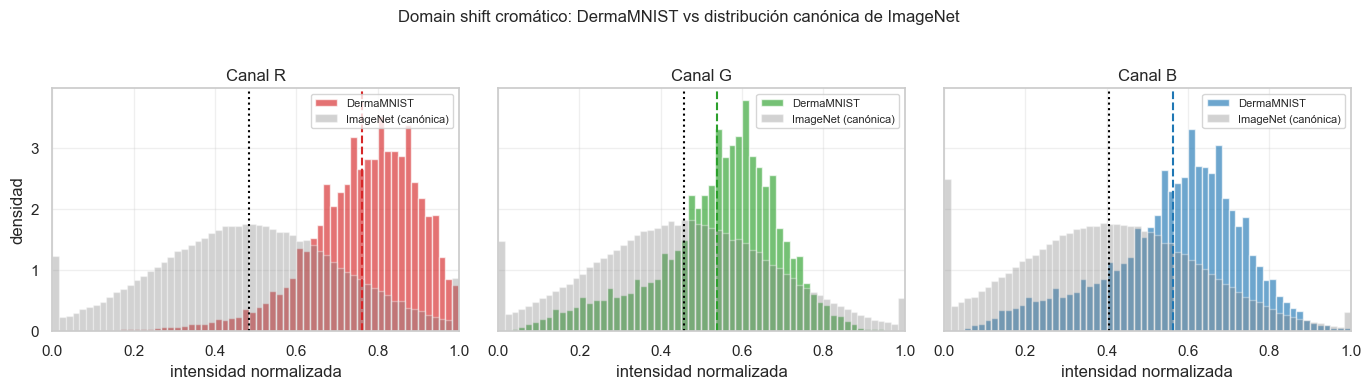


Observaciones clave:
  • Canal R desplazado a la derecha en DermaMNIST (Δ=+0.277).
  • Canal B desplazado a la izquierda (Δ=+0.156): la dermatoscopia carece de cielo, agua, objetos azules.
  • Stds más bajos en DermaMNIST → distribución más concentrada (menos diversidad cromática).


In [14]:
# --- Visualización: histogramas RGB superpuestos ---
# Muestra qué tan estrecha y desplazada es la paleta de DermaMNIST frente a una
# referencia que simula la distribución agregada de ImageNet (gaussiana por canal
# con (mean_i, std_i) canónicos, truncada a [0, 1]).
rng = np.random.default_rng(SEED)
n_samples_ref = x_train_01.shape[0] * x_train_01.shape[1] * x_train_01.shape[2]
n_samples_ref = min(n_samples_ref, 200_000)  # cota para que el plot sea ligero
ref_samples = np.clip(
    rng.normal(loc=imagenet_mean, scale=imagenet_std, size=(n_samples_ref, 3)),
    0.0, 1.0,
)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
channel_names = ["R", "G", "B"]
channel_colors = ["#d62728", "#2ca02c", "#1f77b4"]

for c, (ax, name, color) in enumerate(zip(axes, channel_names, channel_colors)):
    derm_vals = x_train_01[..., c].ravel()
    rng2 = np.random.default_rng(SEED + c)
    derm_vals = rng2.choice(derm_vals, size=min(derm_vals.size, 200_000), replace=False)
    ax.hist(derm_vals,        bins=60, range=(0, 1), density=True, alpha=0.65,
            color=color,      label="DermaMNIST")
    ax.hist(ref_samples[:, c], bins=60, range=(0, 1), density=True, alpha=0.35,
            color="gray",     label="ImageNet (canónica)")
    ax.axvline(derm_mean[c],     color=color, linestyle="--", linewidth=1.5)
    ax.axvline(imagenet_mean[c], color="black", linestyle=":",  linewidth=1.5)
    ax.set_title(f"Canal {name}")
    ax.set_xlabel("intensidad normalizada")
    ax.set_xlim(0, 1)
    if c == 0:
        ax.set_ylabel("densidad")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle("Domain shift cromático: DermaMNIST vs distribución canónica de ImageNet",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "domain_shift_histograms.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nObservaciones clave:")
print(f"  • Canal R desplazado a la derecha en DermaMNIST (Δ={domain_shift_df.loc[0,'Δ_mean']:+.3f}).")
print(f"  • Canal B desplazado a la izquierda (Δ={domain_shift_df.loc[2,'Δ_mean']:+.3f}): "
      "la dermatoscopia carece de cielo, agua, objetos azules.")
print(f"  • Stds más bajos en DermaMNIST → distribución más concentrada (menos diversidad cromática).")

## 6. Pipelines `tf.data` por familia de modelo

Cada familia de modelos requiere un pre-procesamiento distinto, pero el patrón es siempre el mismo: `tf.data.Dataset.from_tensor_slices` → opcional `shuffle` → `map(preprocesamiento + augmentation)` → `batch` → `prefetch`. Toda esa lógica vive en `src.preprocessing.make_dataset` y aquí sólo la instanciamos.

Familias y pre-procesamiento implícito (definido en `src/preprocessing.py`):

| Familia              | Resolución | Normalización                                  | Augment en train |
|----------------------|------------|------------------------------------------------|------------------|
| `"baseline"`         | 28×28      | `/255` → `[0, 1]`                              | sí (28×28)       |
| `"mobilenet"`        | 224×224    | `mobilenet_v2.preprocess_input` → `[-1, 1]`    | sí (224×224)     |
| `"vit"`              | 224×224    | crudo `[0, 255]` (DeiT internaliza la norm.)   | sí (224×224)     |
| `"hybrid_features"`  | 224×224    | igual que mobilenet, **sin augment**           | nunca            |

Reglas que aplica este notebook:

- `train_ds`: `shuffle=True`, `augment=True`.
- `val_ds`, `test_ds`: `shuffle=False`, `augment=False`.
- **`test_ds` SIEMPRE con `shuffle=False`** porque `evaluate_keras_model()` compara `y_pred` contra `y_test` en orden posicional.
- `interpolation = SELECTED_INTERPOLATION` (de la Sección 4) en las familias 224×224. En `"baseline"` el argumento se pasa por consistencia pero `make_dataset` lo ignora a esa resolución.
- `"hybrid_features"` se construirá *bajo demanda* en la Sección 11 (cuando ya exista el extractor de embeddings).

In [15]:
from src.preprocessing import make_dataset

# Helper local: instancia (train, val, test) para una misma familia con la
# convención del taller (shuffle/augment sólo en train; test SIEMPRE shuffle=False).
def build_family_pipelines(family, interpolation):
    train_ds = make_dataset(
        x_train, y_train,
        batch_size=BATCH_SIZE, shuffle=True,
        model_family=family, interpolation=interpolation, augment=True,
    )
    val_ds = make_dataset(
        x_val, y_val,
        batch_size=BATCH_SIZE, shuffle=False,
        model_family=family, interpolation=interpolation, augment=False,
    )
    test_ds = make_dataset(
        x_test, y_test,
        batch_size=BATCH_SIZE, shuffle=False,            # ← invariante exigido por evaluate_keras_model
        model_family=family, interpolation=interpolation, augment=False,
    )
    return train_ds, val_ds, test_ds

# --- Baseline CNN (28x28) ---
baseline_train_ds, baseline_val_ds, baseline_test_ds = build_family_pipelines(
    family="baseline", interpolation=SELECTED_INTERPOLATION,
)

# --- MobileNetV2 (224x224, preprocess_input → [-1, 1]) ---
mobilenet_train_ds, mobilenet_val_ds, mobilenet_test_ds = build_family_pipelines(
    family="mobilenet", interpolation=SELECTED_INTERPOLATION,
)

# --- DeiT / ViT fallback (224x224, crudo [0, 255]) ---
vit_train_ds, vit_val_ds, vit_test_ds = build_family_pipelines(
    family="vit", interpolation=SELECTED_INTERPOLATION,
)

# Tabla resumen — qué dataset usa cada modelo de las secciones siguientes.
pipelines_summary = pd.DataFrame([
    {"familia": "baseline",  "train_ds": "baseline_train_ds",  "val_ds": "baseline_val_ds",  "test_ds": "baseline_test_ds",  "interp": "—"},
    {"familia": "mobilenet", "train_ds": "mobilenet_train_ds", "val_ds": "mobilenet_val_ds", "test_ds": "mobilenet_test_ds", "interp": SELECTED_INTERPOLATION},
    {"familia": "vit",       "train_ds": "vit_train_ds",       "val_ds": "vit_val_ds",       "test_ds": "vit_test_ds",       "interp": SELECTED_INTERPOLATION},
])
print("=== Pipelines tf.data instanciados ===")
print(pipelines_summary.to_string(index=False))

=== Pipelines tf.data instanciados ===
  familia           train_ds           val_ds           test_ds  interp
 baseline  baseline_train_ds  baseline_val_ds  baseline_test_ds       —
mobilenet mobilenet_train_ds mobilenet_val_ds mobilenet_test_ds bicubic
      vit       vit_train_ds       vit_val_ds       vit_test_ds bicubic


In [16]:
# --- Verificación: forma y rango de un batch por familia ---
# Sirve de sanity-check (¿la normalización quedó en el rango esperado?
# ¿la familia mobilenet realmente entrega [-1, 1]?) y documenta los shapes
# que verán los modelos en las Secciones 8-12.

def _inspect_batch(ds, family_name):
    xb, yb = next(iter(ds))
    xb_np = xb.numpy()
    return {
        "familia":    family_name,
        "x.shape":    tuple(xb_np.shape),
        "x.dtype":    str(xb_np.dtype),
        "x.min":      float(xb_np.min()),
        "x.max":      float(xb_np.max()),
        "x.mean":     float(xb_np.mean()),
        "y.shape":    tuple(yb.numpy().shape),
    }

batch_inspection = pd.DataFrame([
    _inspect_batch(baseline_train_ds,  "baseline (train)"),
    _inspect_batch(mobilenet_train_ds, "mobilenet (train)"),
    _inspect_batch(vit_train_ds,       "vit (train)"),
])

print("=== Inspección de un batch por familia ===")
print(batch_inspection.to_string(index=False))

print("\nRangos esperados:")
print("  • baseline  → [0.0, 1.0]   (rescale /255)")
print("  • mobilenet → [-1.0, 1.0]  (mobilenet_v2.preprocess_input)")
print("  • vit       → [0.0, 255.0] (crudo, DeiT normaliza internamente)")

=== Inspección de un batch por familia ===
          familia           x.shape x.dtype     x.min      x.max     x.mean y.shape
 baseline (train)   (32, 28, 28, 3) float32  0.020072   0.995825   0.602484   (32,)
mobilenet (train) (32, 224, 224, 3) float32 -1.000437   1.020270   0.207210   (32,)
      vit (train) (32, 224, 224, 3) float32  0.102263 257.482788 153.400696   (32,)

Rangos esperados:
  • baseline  → [0.0, 1.0]   (rescale /255)
  • mobilenet → [-1.0, 1.0]  (mobilenet_v2.preprocess_input)
  • vit       → [0.0, 255.0] (crudo, DeiT normaliza internamente)


## 7. Class weights

El conteo de la Sección 3 muestra que `nv` (idx 4) domina el train con más de la mitad de las muestras, mientras que clases como `df` y `vasc` aparecen con frecuencias muy bajas. Sin compensación, la pérdida estaría dominada por `nv` y el modelo aprendería a colapsar predicciones sobre la clase mayoritaria — exactamente lo opuesto a lo que pide el taller, que prioriza el **recall de `mel`**.

Calculamos pesos inversos a la frecuencia con `src.training.get_class_weights(y_train)`. La función envuelve `sklearn.utils.class_weight.compute_class_weight("balanced", …)`, de modo que cada clase contribuye al gradiente en proporción inversa a su prevalencia. El diccionario `class_weights` se pasa como `class_weight=` en cada `model.fit()` vía `timed_fit()` en las Secciones 8–12.

> Importante: los class weights se calculan **sólo sobre el split de entrenamiento** — usar val/test contaminaría la evaluación con información del propio conjunto que mide generalización.

In [17]:
from src.training import get_class_weights

class_weights = get_class_weights(y_train)

# Vista legible: pesos junto a conteo y frecuencia relativa para justificar
# numéricamente la corrección que aplican.
class_counts = np.bincount(y_train, minlength=NUM_CLASSES)
class_weights_df = pd.DataFrame({
    "idx":     list(range(NUM_CLASSES)),
    "clase":   class_names,
    "n_train": class_counts,
    "freq %":  (class_counts / class_counts.sum() * 100).round(2),
    "weight":  [round(class_weights[i], 4) for i in range(NUM_CLASSES)],
}).sort_values("weight", ascending=False).reset_index(drop=True)

print("=== Class weights (balanced) sobre y_train ===")
print(class_weights_df.to_string(index=False))

mel_w = class_weights[mel_idx]
nv_w  = class_weights[int(np.argmax(class_counts))]
print(f"\nClase crítica 'mel' (idx {mel_idx}) → peso {mel_w:.3f}")
print(f"Clase mayoritaria '{class_names[int(np.argmax(class_counts))]}' → peso {nv_w:.3f}")
print(f"Razón de compensación mel/mayoritaria = {mel_w / nv_w:.2f}× "
      "(cuánto más castiga la pérdida un error sobre 'mel')")

=== Class weights (balanced) sobre y_train ===
 idx                                           clase  n_train  freq %  weight
   3                                  dermatofibroma       16    1.14 12.5000
   6                                vascular lesions       20    1.43 10.0000
   0 actinic keratoses and intraepithelial carcinoma       45    3.21  4.4444
   1                            basal cell carcinoma       72    5.14  2.7778
   2                   benign keratosis-like lesions      154   11.00  1.2987
   4                                        melanoma      155   11.07  1.2903
   5                                melanocytic nevi      938   67.00  0.2132

Clase crítica 'mel' (idx 4) → peso 1.290
Clase mayoritaria 'melanocytic nevi' → peso 0.213
Razón de compensación mel/mayoritaria = 6.05× (cuánto más castiga la pérdida un error sobre 'mel')


## 8. CNN Baseline (replicando Caso 01)

Punto de comparación obligatorio: una CNN entrenada **desde cero a 28×28**, en la línea de la `dermClass.keras` del Caso 01. Sirve para tres cosas:

1. **Piso de referencia** — todo modelo pre-entrenado debe superarla; si no, la comparativa de la Sección 13 pierde sentido.
2. **Aislamiento del efecto "transfer learning"** — comparte class weights, callbacks y semilla con MobileNet/ViT, así que las diferencias atribuibles a los pesos pre-entrenados son limpias.
3. **Bajo costo de despliegue** — pocos parámetros y latencia baja: si su F1 macro queda cerca del mejor modelo, ganaría en `deployment_score` (Sección 13).

La arquitectura concreta (kernel **5×5** en el primer bloque conv — MEJORA-01 ya aplicada, dos bloques conv→pool, GAP, dense) vive en `src.models.baseline_cnn.build_baseline_cnn`. Aquí sólo construimos, entrenamos con `timed_fit` (mide tiempo de entrenamiento — MEJORA-02) y dibujamos curvas.

In [18]:
from src.models.baseline_cnn import build_baseline_cnn
from src.training import get_callbacks, timed_fit
from src.visualization import plot_history

# --- Construcción del modelo baseline ---
baseline_model = build_baseline_cnn(
    input_shape=(SOURCE_SIZE, SOURCE_SIZE, 3),
    num_classes=NUM_CLASSES,
    lr=LR_BASELINE,
)
baseline_model.summary(line_length=90)
print(f"\nParámetros totales: {baseline_model.count_params():,}")

Model: "baseline_cnn_caso01_approx"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)            │ (None, 28, 28, 3)            │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                       │ (None, 28, 28, 32)           │           2,432 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ batch_normalization                   │ (None, 28, 28, 32)           │             128 │
│ (BatchNormalization)                  │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout (Dropout)                     │ (None, 28, 28, 32)           │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                     │ (None, 28, 28, 64)           │          18,496 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ batch_normalization_1                 │ (None, 28, 28, 64)           │             256 │
│ (BatchNormalization)                  │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)          │ (None, 14, 14, 64)           │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                   │ (None, 14, 14, 64)           │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ global_average_pooling2d              │ (None, 64)                   │               0 │
│ (GlobalAveragePooling2D)              │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense (Dense)                         │ (None, 64)                   │           4,160 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                   │ (None, 64)                   │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                       │ (None, 32)                   │           2,080 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                   │ (None, 32)                   │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                       │ (None, 7)                    │             231 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 27,783 (108.53 KB)

 Trainable params: 27,591 (107.78 KB)

 Non-trainable params: 192 (768.00 B)


Parámetros totales: 27,783


In [19]:
# --- Callbacks: early stopping + reduce LR + checkpoint del mejor val_loss ---
baseline_ckpt = EXPORT_DIR / "baseline_best.keras"
baseline_callbacks = get_callbacks(
    monitor="val_loss",
    patience_es=5,
    patience_lr=2,
    checkpoint_path=baseline_ckpt,
    min_lr=1e-6,
)

# --- Entrenamiento cronometrado (MEJORA-02: el wrapper inyecta el timer) ---
history_baseline, elapsed_baseline = timed_fit(
    model=baseline_model,
    train_ds=baseline_train_ds,
    val_ds=baseline_val_ds,
    epochs=EPOCHS_BASELINE,
    class_weights=class_weights,
    callbacks=baseline_callbacks,
)

print(f"\n=== Baseline CNN entrenada ===")
print(f"  épocas configuradas : {EPOCHS_BASELINE}")
print(f"  épocas reales       : {len(history_baseline.history['loss'])}  (puede ser menor si EarlyStopping cortó)")
print(f"  tiempo entrenamiento: {elapsed_baseline:.1f} s")
print(f"  mejor val_loss      : {min(history_baseline.history['val_loss']):.4f}")
print(f"  checkpoint guardado : {baseline_ckpt}")

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3679 - loss: 1.9380 - val_accuracy: 0.0160 - val_loss: 1.8947 - learning_rate: 0.0010
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4707 - loss: 1.8546 - val_accuracy: 0.1200 - val_loss: 1.9540 - learning_rate: 0.0010
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4107 - loss: 1.8171 - val_accuracy: 0.0520 - val_loss: 1.9570 - learning_rate: 0.0010
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4571 - loss: 1.7492 - val_accuracy: 0.1480 - val_loss: 1.8749 - learning_rate: 2.0000e-04
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4729 - loss: 1.7586 - val_accuracy: 0.1440 - val_loss: 1.9419 - learning_rate: 2.0000e-04
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4564 - loss: 1.7234 - val_accuracy: 0.1640 - val_loss: 1.9519 - learning_rate: 2.0000e-04
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4636 - loss: 1.69

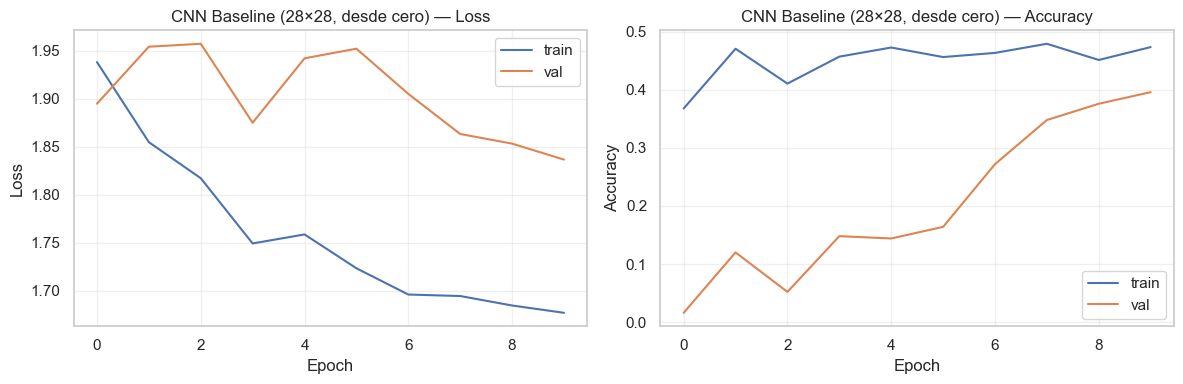

In [20]:
# --- Curvas de aprendizaje del baseline ---
plot_history(
    history_baseline,
    model_name="CNN Baseline (28×28, desde cero)",
    save_path=FIGURES_DIR / "learning_curves_baseline.png",
)

## 9. MobileNetV2 — Feature Extraction (T1)

Primera fase del transfer learning: **base congelada**. Importamos MobileNetV2 con pesos de ImageNet, le quitamos la cabeza original y le acoplamos un clasificador denso sobre la GAP (`gap`). Sólo las capas nuevas entrenan; los pesos pre-entrenados quedan fijos. Esto:

- Da una señal rápida de **cuán transferibles** son las features de ImageNet a dermatoscopia (Sección 5: domain shift).
- Sirve de **punto de partida ortogonal** para el Fine-Tuning de la Sección 10 — si arrancamos FT desde un FE ya convergido, evitamos perturbar los pesos pre-entrenados con gradientes ruidosos de una cabeza sin entrenar.

**Fixes aplicados:**

- **BUG-08**: el entrenamiento se ejecuta de verdad con `timed_fit()` (antes la celda estaba truncada).
- **BUG-05**: `history_mobilenet_fe` viene del retorno de `timed_fit`, no de un `model.fit()` suelto.
- **BUG-02**: tras entrenar, hacemos `snapshot_model()` ANTES de cualquier `unfreeze`. Sin este snapshot, la Sección 10 modificaría in-place el modelo FE y perderíamos su estado convergido para la comparación FE vs FT de la Sección 13.

In [21]:
from src.models.mobilenetv2 import build_mobilenet_fe, snapshot_model

# --- Construcción: base MobileNetV2 congelada + cabeza nueva ---
mobilenet_fe_model, mobilenet_base = build_mobilenet_fe(
    num_classes=NUM_CLASSES,
    input_shape=(TARGET_SIZE, TARGET_SIZE, 3),
    lr=LR_FE,
    dropout=0.3,
)

# Sanity check: la base debe estar congelada en este punto.
trainable_params  = int(sum(np.prod(v.shape) for v in mobilenet_fe_model.trainable_weights))
total_params      = mobilenet_fe_model.count_params()
frozen_base_layers = sum(1 for L in mobilenet_base.layers if not L.trainable)

print(f"=== MobileNetV2 — Feature Extraction (base congelada) ===")
print(f"  parámetros totales      : {total_params:,}")
print(f"  parámetros entrenables  : {trainable_params:,}   "
      f"({trainable_params / total_params * 100:.2f}%)")
print(f"  capas congeladas (base) : {frozen_base_layers} / {len(mobilenet_base.layers)}")
mobilenet_fe_model.summary(line_length=110)

=== MobileNetV2 — Feature Extraction (base congelada) ===
  parámetros totales      : 2,266,951
  parámetros entrenables  : 8,967   (0.40%)
  capas congeladas (base) : 154 / 154


Model: "mobilenetv2_feature_extraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                   ┃ Output Shape                        ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)                     │ (None, 224, 224, 3)                 │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ mobilenetv2_1.00_224 (Functional)              │ (None, 7, 7, 1280)                  │           2,257,984 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ gap (GlobalAveragePooling2D)                   │ (None, 1280)                        │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ dropout (Dropout)                              │ (None, 1280)                        │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ predictions (Dense)                            │ (None, 7)                           │               8,967 │
└────────────────────────────────────────────────┴─────────────────────────────────────┴─────────────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
# --- Callbacks + entrenamiento cronometrado (FIX BUG-08, BUG-05) ---
mobilenet_fe_ckpt = EXPORT_DIR / "mobilenetv2_fe_best.keras"
mobilenet_fe_callbacks = get_callbacks(
    monitor="val_loss",
    patience_es=4,
    patience_lr=2,
    checkpoint_path=mobilenet_fe_ckpt,
    min_lr=1e-6,
)

history_mobilenet_fe, elapsed_mobilenet_fe = timed_fit(
    model=mobilenet_fe_model,
    train_ds=mobilenet_train_ds,
    val_ds=mobilenet_val_ds,
    epochs=EPOCHS_MOBILENET_FE,
    class_weights=class_weights,
    callbacks=mobilenet_fe_callbacks,
)

print(f"\n=== MobileNetV2 FE entrenado ===")
print(f"  épocas configuradas : {EPOCHS_MOBILENET_FE}")
print(f"  épocas reales       : {len(history_mobilenet_fe.history['loss'])}")
print(f"  tiempo entrenamiento: {elapsed_mobilenet_fe:.1f} s")
print(f"  mejor val_loss      : {min(history_mobilenet_fe.history['val_loss']):.4f}")
print(f"  checkpoint guardado : {mobilenet_fe_ckpt}")

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 282ms/step - accuracy: 0.2214 - loss: 2.2174 - val_accuracy: 0.4200 - val_loss: 1.4624 - learning_rate: 0.0010
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 262ms/step - accuracy: 0.3536 - loss: 1.8154 - val_accuracy: 0.1960 - val_loss: 2.0555 - learning_rate: 0.0010
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 258ms/step - accuracy: 0.3857 - loss: 1.6385 - val_accuracy: 0.4000 - val_loss: 1.5923 - learning_rate: 0.0010
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 266ms/step - accuracy: 0.3943 - loss: 1.5607 - val_accuracy: 0.4520 - val_loss: 1.3413 - learning_rate: 2.0000e-04
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 258ms/step - accuracy: 0.4750 - loss: 1.4911 - val_accuracy: 0.4400 - val_loss: 1.4600 - learning_rate: 2.0000e-04

=== MobileNetV2 FE entrenado ===
  épocas configuradas : 5
  épocas reales       : 5
  tiempo entrenamiento: 61.7 s
  mejor val_loss      : 1.3413
  checkpoint guardado : artifacts_taller_02\mobilenetv2_fe_best.keras


In [23]:
# --- Snapshot del modelo FE convergido ANTES de cualquier unfreeze (FIX BUG-02) ---
# snapshot_model() devuelve un modelo independiente con los mismos pesos pero
# completamente desacoplado del objeto que la Sección 10 va a mutar.
mobilenet_fe_snapshot = snapshot_model(mobilenet_fe_model, lr=LR_FE)
print(f"Snapshot FE creado: {mobilenet_fe_snapshot.name} "
      f"({mobilenet_fe_snapshot.count_params():,} params)")
print("→ Este objeto se evaluará intacto en la Sección 13 como 'mobilenetv2_fe'.")

Snapshot FE creado: mobilenetv2_feature_extraction (2,266,951 params)
→ Este objeto se evaluará intacto en la Sección 13 como 'mobilenetv2_fe'.


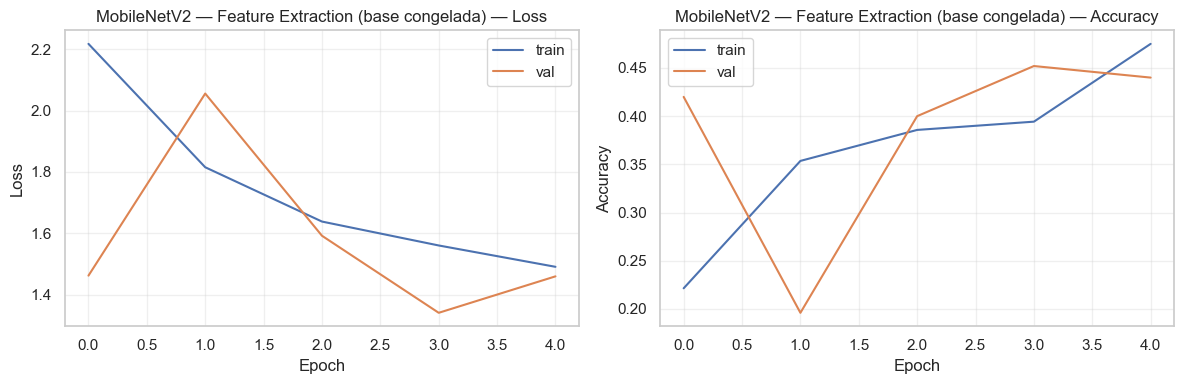

In [24]:
# --- Curvas de aprendizaje FE ---
plot_history(
    history_mobilenet_fe,
    model_name="MobileNetV2 — Feature Extraction (base congelada)",
    save_path=FIGURES_DIR / "learning_curves_mobilenet_fe.png",
)

## 10. MobileNetV2 — Fine-Tuning (T2, T3, T4)

Segunda fase del transfer learning: descongelamos los **últimos 30 layers** de la base y reentrenamos con un learning rate muy pequeño (`LR_FT = 1e-5`). La intuición es:

- Los primeros bloques de MobileNet codifican bordes/colores genéricos transferibles desde ImageNet → no hay que tocarlos.
- Los últimos bloques codifican features semánticas específicas del dominio fuente (objetos, animales, escenas) → reentrenarlos permite reespecializarlos al microdominio dermatoscópico documentado en la Sección 5.
- LR pequeño + base previamente convergida vía FE → evitamos *catastrophic forgetting* de las features útiles.

**Fixes aplicados:**

- **BUG-09**: `unfreeze_for_finetuning(..., n_unfreeze=30, ...)` — el unfreeze agresivo de antes (toda la base) se cambió por uno selectivo en `src/models/mobilenetv2.py`.
- **BUG-03**: aquí *sí* se construye y entrena `mobilenet_ft_model` (antes la sección era esqueleto).
- **BUG-05**: `history_mobilenet_ft` viene del retorno de `timed_fit`.

El objeto `mobilenet_ft_model` que sale de esta sección es el mismo `mobilenet_fe_model` post-unfreeze (mutado in-place). El estado convergido pre-FT está preservado en `mobilenet_fe_snapshot` (Sección 9) para la comparación de la Sección 13.

In [25]:
from src.models.mobilenetv2 import unfreeze_for_finetuning
from src.visualization import merge_histories

# --- Snapshot de métricas pre-unfreeze (para el análisis FE vs FT más abajo) ---
pre_ft_trainable_params = int(sum(np.prod(v.shape) for v in mobilenet_fe_model.trainable_weights))
pre_ft_val_loss = float(history_mobilenet_fe.history["val_loss"][-1])
pre_ft_val_acc  = float(history_mobilenet_fe.history.get(
    "val_accuracy", history_mobilenet_fe.history.get("val_acc", [np.nan])
)[-1])

# --- Unfreeze + recompilación con LR_FT (FIX BUG-09: n_unfreeze=30) ---
mobilenet_ft_model = unfreeze_for_finetuning(
    model=mobilenet_fe_model,
    base=mobilenet_base,
    n_unfreeze=30,
    lr=LR_FT,
)

post_ft_trainable_params = int(sum(np.prod(v.shape) for v in mobilenet_ft_model.trainable_weights))
unfrozen_base_layers = sum(1 for L in mobilenet_base.layers if L.trainable)

print(f"=== MobileNetV2 — Fine-Tuning (últimos 30 layers descongelados) ===")
print(f"  capas descongeladas en la base : {unfrozen_base_layers} / {len(mobilenet_base.layers)}")
print(f"  parámetros entrenables antes   : {pre_ft_trainable_params:,}")
print(f"  parámetros entrenables después : {post_ft_trainable_params:,}   "
      f"(×{post_ft_trainable_params / max(pre_ft_trainable_params, 1):.1f})")
print(f"  learning rate FT               : {LR_FT}")

=== MobileNetV2 — Fine-Tuning (últimos 30 layers descongelados) ===
  capas descongeladas en la base : 30 / 154
  parámetros entrenables antes   : 8,967
  parámetros entrenables después : 1,535,367   (×171.2)
  learning rate FT               : 1e-05


In [26]:
# --- Callbacks específicos para FT: paciencia ES más larga porque la dinámica
#     con base descongelada y LR pequeño es más lenta y más ruidosa. ---
mobilenet_ft_ckpt = EXPORT_DIR / "mobilenetv2_ft_best.keras"
mobilenet_ft_callbacks = get_callbacks(
    monitor="val_loss",
    patience_es=5,
    patience_lr=2,
    checkpoint_path=mobilenet_ft_ckpt,
    min_lr=1e-7,            # más bajo que FE: estamos ya operando en LR=1e-5
)

# --- Entrenamiento cronometrado del FT ---
history_mobilenet_ft, elapsed_mobilenet_ft = timed_fit(
    model=mobilenet_ft_model,
    train_ds=mobilenet_train_ds,
    val_ds=mobilenet_val_ds,
    epochs=EPOCHS_MOBILENET_FT,
    class_weights=class_weights,
    callbacks=mobilenet_ft_callbacks,
)

print(f"\n=== MobileNetV2 FT entrenado ===")
print(f"  épocas configuradas : {EPOCHS_MOBILENET_FT}")
print(f"  épocas reales       : {len(history_mobilenet_ft.history['loss'])}")
print(f"  tiempo entrenamiento: {elapsed_mobilenet_ft:.1f} s")
print(f"  mejor val_loss      : {min(history_mobilenet_ft.history['val_loss']):.4f}")
print(f"  checkpoint guardado : {mobilenet_ft_ckpt}")

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 333ms/step - accuracy: 0.1529 - loss: 2.4950 - val_accuracy: 0.5240 - val_loss: 1.2761 - learning_rate: 1.0000e-05
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 316ms/step - accuracy: 0.1957 - loss: 2.0931 - val_accuracy: 0.5400 - val_loss: 1.2603 - learning_rate: 1.0000e-05
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 357ms/step - accuracy: 0.2350 - loss: 1.9404 - val_accuracy: 0.5560 - val_loss: 1.2527 - learning_rate: 1.0000e-05
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 327ms/step - accuracy: 0.2786 - loss: 1.7630 - val_accuracy: 0.5520 - val_loss: 1.2330 - learning_rate: 1.0000e-05
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 310ms/step - accuracy: 0.2979 - loss: 1.5981 - val_accuracy: 0.5480 - val_loss: 1.2527 - learning_rate: 1.0000e-05

=== MobileNetV2 FT entrenado ===
  épocas configuradas : 5
  épocas reales       : 5
  tiempo entrenamiento: 77.8 s
  mejor val_loss      : 1.2330
  checkpoint guardado : artifacts_taller_02\mobilenetv2_ft_best.keras


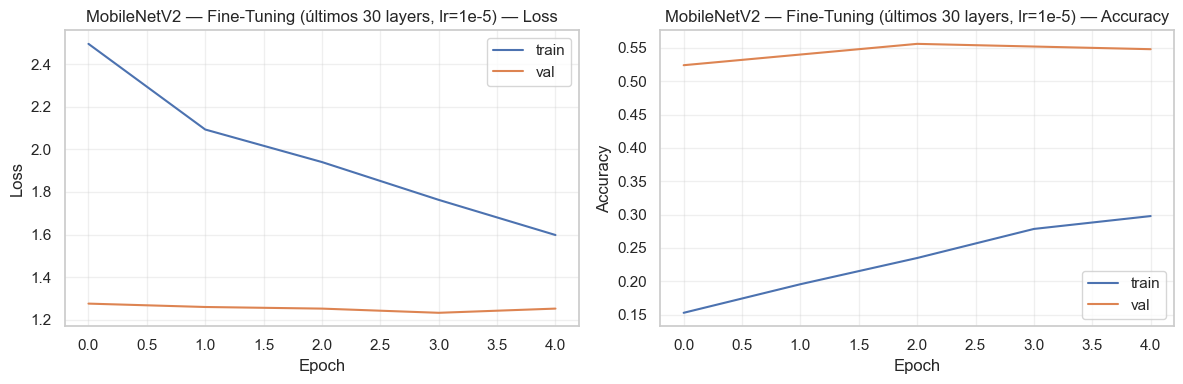

In [27]:
# --- Curvas de aprendizaje del FT en aislamiento ---
plot_history(
    history_mobilenet_ft,
    model_name="MobileNetV2 — Fine-Tuning (últimos 30 layers, lr=1e-5)",
    save_path=FIGURES_DIR / "learning_curves_mobilenet_ft.png",
)

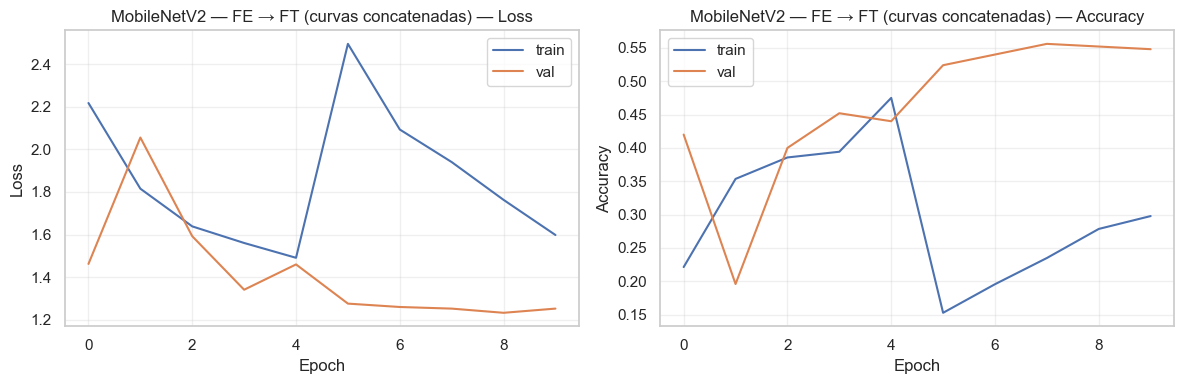

=== FE vs FT — métricas comparables ===
           métrica    FE        FT
     épocas reales     5         5
tiempo entren. (s)  61.7      77.8
params entrenables 8,967 1,535,367
    val_loss final  1.46    1.2527
val_accuracy final  0.44     0.548

Δ val_loss (FT − FE)     : -0.2073   (mejora)
Δ val_accuracy (FT − FE) : +0.1080    (mejora)
Tiempo total FE+FT       : 139.5 s  (FE = 44%, FT = 56%)


In [28]:
# --- Análisis de convergencia FE vs FT (T3 + T4) ---
# Curvas concatenadas: las épocas de FT se grafican a continuación de las de FE,
# así se ve si el FT *bajó* el val_loss respecto del último punto del FE.
merged_history = merge_histories(history_mobilenet_fe, history_mobilenet_ft)
plot_history(
    merged_history,
    model_name="MobileNetV2 — FE → FT (curvas concatenadas)",
    save_path=FIGURES_DIR / "learning_curves_mobilenet_fe_ft.png",
)

post_ft_val_loss = float(history_mobilenet_ft.history["val_loss"][-1])
post_ft_val_acc  = float(history_mobilenet_ft.history.get(
    "val_accuracy", history_mobilenet_ft.history.get("val_acc", [np.nan])
)[-1])

fe_vs_ft_df = pd.DataFrame([
    {"métrica": "épocas reales",         "FE": len(history_mobilenet_fe.history["loss"]),
                                          "FT": len(history_mobilenet_ft.history["loss"])},
    {"métrica": "tiempo entren. (s)",    "FE": round(elapsed_mobilenet_fe, 1),
                                          "FT": round(elapsed_mobilenet_ft, 1)},
    {"métrica": "params entrenables",    "FE": f"{pre_ft_trainable_params:,}",
                                          "FT": f"{post_ft_trainable_params:,}"},
    {"métrica": "val_loss final",        "FE": round(pre_ft_val_loss, 4),
                                          "FT": round(post_ft_val_loss, 4)},
    {"métrica": "val_accuracy final",    "FE": round(pre_ft_val_acc, 4),
                                          "FT": round(post_ft_val_acc, 4)},
])
print("=== FE vs FT — métricas comparables ===")
print(fe_vs_ft_df.to_string(index=False))

delta_loss = post_ft_val_loss - pre_ft_val_loss
delta_acc  = post_ft_val_acc  - pre_ft_val_acc
total_time = elapsed_mobilenet_fe + elapsed_mobilenet_ft

print(f"\nΔ val_loss (FT − FE)     : {delta_loss:+.4f}   "
      f"({'mejora' if delta_loss < 0 else 'empeora'})")
print(f"Δ val_accuracy (FT − FE) : {delta_acc:+.4f}    "
      f"({'mejora' if delta_acc > 0 else 'empeora o estable'})")
print(f"Tiempo total FE+FT       : {total_time:.1f} s  "
      f"(FE = {elapsed_mobilenet_fe/total_time*100:.0f}%, FT = {elapsed_mobilenet_ft/total_time*100:.0f}%)")

if delta_loss >= 0:
    print("\n⚠ El FT no mejoró val_loss frente al estado FE convergido. Posibles causas:")
    print("  • LR_FT demasiado alto/bajo, n_unfreeze excesivo, o EPOCHS_MOBILENET_FT insuficiente.")
    print("  • La evaluación final (Sección 13) se hará igualmente con AMBOS modelos "
          "(snapshot FE + FT), así que el reporte queda completo.")

## 11. Híbrido CNN features + Random Forest (T5)

Enfoque opcional pero documentado en el enunciado: usar el **MobileNetV2 fine-tuneado** como **extractor de embeddings fijo** y entrenar un **Random Forest** sobre esos vectores GAP de 1280 dim. La hipótesis es que un clasificador no paramétrico, robusto a desbalance vía `class_weight="balanced_subsample"`, puede explotar mejor el espacio latente especializado por el FT que la cabeza densa nativa — sobre todo en clases raras.

Pipeline concreto:

1. `build_embedding_extractor(mobilenet_ft_model, layer_name="gap")` → un sub-modelo que devuelve el vector GAP de 1280 dim.
2. `make_dataset(..., model_family="hybrid_features", augment=False, shuffle=False)` para los 3 splits — sin augment, sin shuffle, mismo `interpolation` que MobileNet.
3. `.predict()` sobre cada split → matrices `Xtr_emb`, `Xva_emb`, `Xte_emb`.
4. `Pipeline(StandardScaler → RandomForestClassifier(300 árboles, balanced_subsample))` con `random_state=SEED`.
5. Fit, val sanity-check, predict en test.
6. Resultado serializado en `hybrid_results` (contrato BUG-04).
7. Persistencia opcional en `artifacts_taller_02/rf_pipeline.joblib`.

Toda la sección queda envuelta en `if RUN_HYBRID_RF: ... else: hybrid_results = None`, de modo que apagar la flag no rompa secciones posteriores.

In [29]:
from src.models.mobilenetv2 import build_embedding_extractor

if not RUN_HYBRID_RF:
    hybrid_results = None
    print("RUN_HYBRID_RF=False → Sección 11 saltada. hybrid_results = None.")
else:
    # --- (1) Extractor de embeddings desde el FT (capa 'gap', 1280-d) ---
    embedding_extractor = build_embedding_extractor(mobilenet_ft_model, layer_name="gap")
    emb_dim = embedding_extractor.output_shape[-1]
    print(f"=== Embedding extractor listo ===")
    print(f"  capa fuente           : 'gap'")
    print(f"  dimensión del vector  : {emb_dim}")
    print(f"  parámetros (frozen)   : {embedding_extractor.count_params():,}")

    # --- (2) Pipelines hybrid_features: sin augment, sin shuffle, en los 3 splits ---
    hybrid_train_ds = make_dataset(
        x_train, y_train, batch_size=BATCH_SIZE, shuffle=False,
        model_family="hybrid_features", interpolation=SELECTED_INTERPOLATION, augment=False,
    )
    hybrid_val_ds = make_dataset(
        x_val, y_val, batch_size=BATCH_SIZE, shuffle=False,
        model_family="hybrid_features", interpolation=SELECTED_INTERPOLATION, augment=False,
    )
    hybrid_test_ds = make_dataset(
        x_test, y_test, batch_size=BATCH_SIZE, shuffle=False,
        model_family="hybrid_features", interpolation=SELECTED_INTERPOLATION, augment=False,
    )

    # --- (3) Extracción de embeddings (drop labels antes del predict) ---
    t0 = time.perf_counter()
    Xtr_emb = embedding_extractor.predict(hybrid_train_ds.map(lambda x, y: x), verbose=0)
    Xva_emb = embedding_extractor.predict(hybrid_val_ds.map(lambda x, y: x),   verbose=0)
    Xte_emb = embedding_extractor.predict(hybrid_test_ds.map(lambda x, y: x),  verbose=0)
    emb_time = time.perf_counter() - t0

    print(f"\n=== Embeddings extraídos ===")
    print(f"  Xtr_emb : {Xtr_emb.shape}")
    print(f"  Xva_emb : {Xva_emb.shape}")
    print(f"  Xte_emb : {Xte_emb.shape}")
    print(f"  tiempo total de extracción : {emb_time:.1f} s")

=== Embedding extractor listo ===
  capa fuente           : 'gap'
  dimensión del vector  : 1280
  parámetros (frozen)   : 2,257,984

=== Embeddings extraídos ===
  Xtr_emb : (1400, 1280)
  Xva_emb : (250, 1280)
  Xte_emb : (500, 1280)
  tiempo total de extracción : 15.9 s


In [30]:
if RUN_HYBRID_RF:
    # --- (4) Pipeline RF: scaler + bosque balanceado por subsampling ---
    rf_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            random_state=SEED,
            class_weight="balanced_subsample",
            n_jobs=-1,
        )),
    ])

    # --- (5) Fit cronometrado sobre embeddings de train ---
    t0 = time.perf_counter()
    rf_pipeline.fit(Xtr_emb, y_train)
    rf_train_time = time.perf_counter() - t0

    # Validación rápida sólo para detectar colapso (no para early stopping).
    from sklearn.metrics import f1_score
    rf_val_pred = rf_pipeline.predict(Xva_emb)
    rf_val_f1   = float(f1_score(y_val, rf_val_pred, average="macro"))

    # --- (6) Predicción sobre test ---
    rf_test_pred = rf_pipeline.predict(Xte_emb)

    # --- Contrato BUG-04: hybrid_results con todo lo que necesita la Sección 13 ---
    hybrid_results = {
        "model_name":      "mobilenetv2_embeddings_rf",
        "model_family":    "hybrid",
        "y_true":          y_test,
        "y_pred":          rf_test_pred,
        "clf":             rf_pipeline,
        "x_features_test": Xte_emb,
        "train_time_s":    float(rf_train_time + emb_time),  # extracción + fit
        "benchmark_batch": Xte_emb[:BATCH_SIZE],
    }

    print(f"=== Random Forest entrenado sobre embeddings GAP ===")
    print(f"  n_estimators            : {rf_pipeline.named_steps['rf'].n_estimators}")
    print(f"  class_weight            : balanced_subsample")
    print(f"  tiempo fit              : {rf_train_time:.1f} s")
    print(f"  tiempo total (ext+fit)  : {hybrid_results['train_time_s']:.1f} s")
    print(f"  val macro-F1 (sanity)   : {rf_val_f1:.4f}")
    print(f"  hybrid_results.keys()   : {sorted(hybrid_results.keys())}")

=== Random Forest entrenado sobre embeddings GAP ===
  n_estimators            : 300
  class_weight            : balanced_subsample
  tiempo fit              : 0.9 s
  tiempo total (ext+fit)  : 16.8 s
  val macro-F1 (sanity)   : 0.1467
  hybrid_results.keys()   : ['benchmark_batch', 'clf', 'model_family', 'model_name', 'train_time_s', 'x_features_test', 'y_pred', 'y_true']


In [31]:
if RUN_HYBRID_RF:
    # --- (7) Persistencia del pipeline (útil si el ganador en Sección 13 fuera el híbrido) ---
    rf_path = EXPORT_DIR / "rf_pipeline.joblib"
    joblib.dump(rf_pipeline, rf_path)
    print(f"Pipeline RF serializado en: {rf_path}")
    print(f"Tamaño en disco         : {rf_path.stat().st_size / 1024:.1f} KB")

Pipeline RF serializado en: artifacts_taller_02\rf_pipeline.joblib
Tamaño en disco         : 15879.1 KB


## 12. DeiT / Small ViT (T6)

Cuarta arquitectura: una basada en **atención** en vez de convoluciones. La intención no es competir en F1 con MobileNet — el dataset es pequeño y ViTs son notoriamente *data-hungry* — sino tener evidencia empírica del **trade-off CNN vs Transformer** que pide el enunciado (T6).

`src.models.vit_fallback.try_load_deit(num_classes, lr)` resuelve esto con una estrategia doble (BUG-07 ya resuelto):

1. **Intenta** cargar un DeiT-tiny pre-entrenado vía `keras_hub` recorriendo una lista de presets conocidos. Si alguno resuelve, devuelve `(model, "deit_tiny")`.
2. **Si falla** (paquete ausente, preset no disponible, error de descarga), construye un **ViT compacto desde cero** con los `Patches` / `PatchEncoder` registrados en `src.models.custom_layers` y devuelve `(model, "small_vit_scratch")`.

Esto garantiza que la sección **siempre** produzca un `deit_model` evaluable, sin importar el entorno. Toda la sección queda envuelta en `if RUN_DEIT: ... else: deit_model = None; deit_family = None; history_deit = None`.

In [32]:
from src.models.vit_fallback import try_load_deit

if not RUN_DEIT:
    deit_model         = None
    deit_family        = None
    history_deit       = None
    elapsed_deit       = 0.0
    print("RUN_DEIT=False → Sección 12 saltada.")
    print("  deit_model = None, deit_family = None, history_deit = None")
else:
    # --- Construcción: DeiT pre-entrenado si keras_hub lo provee, ViT scratch si no ---
    deit_model, deit_family = try_load_deit(num_classes=NUM_CLASSES, lr=LR_VIT)

    print(f"=== Arquitectura ViT seleccionada ===")
    print(f"  familia    : {deit_family}")
    print(f"  HAS_KERAS_HUB : {HAS_KERAS_HUB}")
    print(f"  parámetros : {deit_model.count_params():,}")
    if deit_family == "small_vit_scratch":
        print("  ⚠ Fallback activo: ViT compacto desde cero "
              "(esperar F1 menor que MobileNet por falta de pre-entrenamiento).")
    deit_model.summary(line_length=110)

100%|██████████| 615/615 [00:00<00:00, 617kB/s]


100%|██████████| 3.38k/3.38k [00:00<00:00, 3.47MB/s]



Preset 'deit_tiny_distilled_patch16_224_imagenet' no disponible (TypeError). Intentando siguiente...
Preset 'deit_tiny_patch16_224_imagenet' no disponible (ValueError). Intentando siguiente...
Preset 'vit_tiny_patch16_224_imagenet' no disponible (ValueError). Intentando siguiente...
Ningún preset DeiT disponible. Usando Small ViT desde cero.
=== Arquitectura ViT seleccionada ===
  familia    : small_vit
  HAS_KERAS_HUB : True
  parámetros : 411,719


Model: "small_vit_from_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                   ┃ Output Shape              ┃          Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)     │ (None, 224, 224, 3)       │                0 │ -                          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ patches (Patches)              │ (None, None, 768)         │                0 │ input_layer_6[0][0]        │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ patch_encoder (PatchEncoder)   │ (None, 196, 64)           │           61,760 │ patches[0][0]              │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ layer_normalization            │ (None, 196, 64)           │              128 │ patch_encoder[0][0]        │
│ (LayerNormalization)           │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ multi_head_attention           │ (None, 196, 64)           │           66,368 │ layer_normalization[0][0], │
│ (MultiHeadAttention)           │                           │                  │ layer_normalization[0][0]  │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ add (Add)                      │ (None, 196, 64)           │                0 │ multi_head_attention[0][0… │
│                                │                           │                  │ patch_encoder[0][0]        │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ layer_normalization_1          │ (None, 196, 64)           │              128 │ add[0][0]                  │
│ (LayerNormalization)           │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ dense_4 (Dense)                │ (None, 196, 128)          │            8,320 │ layer_normalization_1[0][… │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ dropout_17 (Dropout)           │ (None, 196, 128)          │                0 │ dense_4[0][0]              │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ dense_5 (Dense)                │ (None, 196, 64)           │            8,256 │ dropout_17[0][0]           │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ add_1 (Add)                    │ (None, 196, 64)           │                0 │ dense_5[0][0], add[0][0]   │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ layer_normalization_2          │ (None, 196, 64)           │              128 │ add_1[0][0]                │
│ (LayerNormalization)           │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ multi_head_attention_1         │ (None, 196, 64)           │           66,368 │ layer_normalization_2[0][… │
│ (MultiHeadAttention)           │                           │                  │ layer_normalization_2[0][… │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ add_2 (Add)                    │ (None, 196, 64)           │                0 │ multi_head_attention_1[0]… │
│   

 Total params: 411,719 (1.57 MB)

 Trainable params: 411,719 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
if RUN_DEIT:
    # --- Callbacks específicos para ViT: paciencia ES algo mayor porque la curva
    #     de un transformer a baja resolución es ruidosa, especialmente en el scratch. ---
    deit_ckpt = EXPORT_DIR / "deit_best.keras"
    deit_callbacks = get_callbacks(
        monitor="val_loss",
        patience_es=5,
        patience_lr=2,
        checkpoint_path=deit_ckpt,
        min_lr=1e-7,
    )

    # --- Entrenamiento cronometrado sobre el pipeline 'vit' (crudo [0, 255]) ---
    history_deit, elapsed_deit = timed_fit(
        model=deit_model,
        train_ds=vit_train_ds,
        val_ds=vit_val_ds,
        epochs=EPOCHS_VIT,
        class_weights=class_weights,
        callbacks=deit_callbacks,
    )

    print(f"\n=== {deit_family} entrenado ===")
    print(f"  épocas configuradas : {EPOCHS_VIT}")
    print(f"  épocas reales       : {len(history_deit.history['loss'])}")
    print(f"  tiempo entrenamiento: {elapsed_deit:.1f} s")
    print(f"  mejor val_loss      : {min(history_deit.history['val_loss']):.4f}")
    print(f"  checkpoint guardado : {deit_ckpt}")

Epoch 1/4
44/44 ━━━━━━━━━━━━━━━━━━━━ 17s 232ms/step - accuracy: 0.4164 - loss: 2.0893 - val_accuracy: 0.0520 - val_loss: 1.9266 - learning_rate: 5.0000e-05
Epoch 2/4
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 216ms/step - accuracy: 0.2157 - loss: 2.0023 - val_accuracy: 0.0520 - val_loss: 2.0258 - learning_rate: 5.0000e-05
Epoch 3/4
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 211ms/step - accuracy: 0.1829 - loss: 1.9790 - val_accuracy: 0.0640 - val_loss: 2.0264 - learning_rate: 5.0000e-05
Epoch 4/4
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 213ms/step - accuracy: 0.1529 - loss: 1.9934 - val_accuracy: 0.0320 - val_loss: 2.0415 - learning_rate: 1.0000e-05

=== small_vit entrenado ===
  épocas configuradas : 4
  épocas reales       : 4
  tiempo entrenamiento: 45.8 s
  mejor val_loss      : 1.9266
  checkpoint guardado : artifacts_taller_02\deit_best.keras


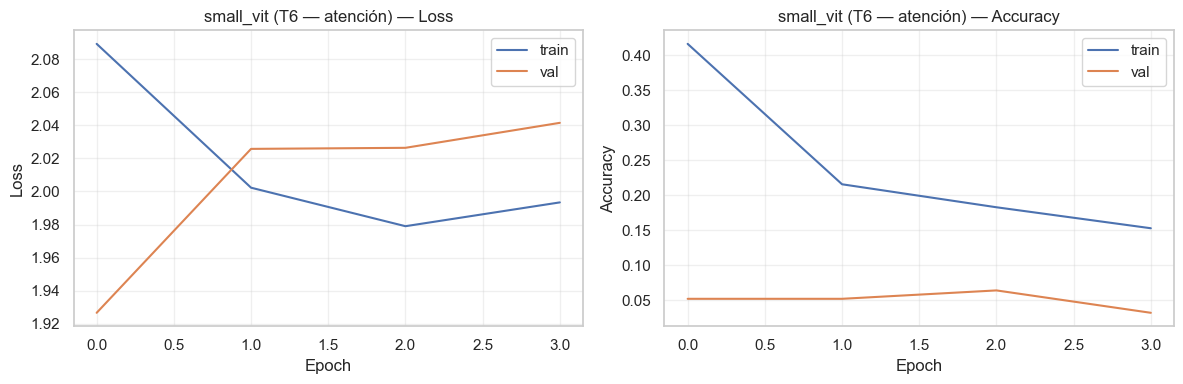

In [34]:
if RUN_DEIT:
    # --- Curvas de aprendizaje del ViT/DeiT ---
    plot_history(
        history_deit,
        model_name=f"{deit_family} (T6 — atención)",
        save_path=FIGURES_DIR / "learning_curves_vit.png",
    )

## 13. Evaluación consolidada

Cierre del taller: todos los modelos entrenados se evalúan sobre **el mismo `test_ds`** (orden fijo, `shuffle=False`) con `evaluate_keras_model` / `evaluate_rf_model`, lo que produce un `result dict` por modelo con accuracy, F1 macro, **recall de `mel`**, parámetros, tiempo de entrenamiento y latencia de inferencia medida con `benchmark_inference_time` (`n_runs=20`, `warmup=3`).

Se cubren los cinco entregables de análisis del enunciado:

1. **Tabla comparativa** ordenada por F1 macro (`build_comparison_df`).
2. **Matrices de confusión side-by-side** (`plot_confusion_side_by_side`).
3. **Trade-off F1 vs latencia vs parámetros** (`plot_tradeoff_scatter`) con un `deployment_score` ponderado.
4. **Δ vs baseline** — cuantifica la mejora de `mel_recall` (E3) por encima de la CNN desde cero, que funciona como proxy de la `dermClass.keras` del Caso 01.
5. **Análisis de overfitting** (E4) — gap train/val en la última época por modelo.

El `benchmark_batch` de cada modelo se toma de su propio `test_ds` (regla del plan: nunca sintético), salvo el modelo híbrido RF, que recibe el sub-batch de embeddings preparado en la Sección 11.

In [38]:
from src.evaluation import evaluate_keras_model, evaluate_rf_model, build_comparison_df, compute_deployment_score
from src.visualization import plot_confusion_side_by_side, plot_tradeoff_scatter

def _first_batch_features(ds):
    """Devuelve el tensor X del primer batch de un tf.data.Dataset (sin labels)."""
    for x_batch, _ in ds:
        return x_batch

# --- Batches reales de cada test_ds para benchmark_inference_time ---
baseline_bench_batch  = _first_batch_features(baseline_test_ds)
mobilenet_bench_batch = _first_batch_features(mobilenet_test_ds)
vit_bench_batch       = _first_batch_features(vit_test_ds) if RUN_DEIT else None

# --- Evaluación de cada modelo Keras ---
all_results = []

all_results.append(evaluate_keras_model(
    model=baseline_model,
    test_ds=baseline_test_ds,
    y_test=y_test,
    mel_idx=mel_idx,
    model_name="baseline_cnn",
    model_family="baseline",
    train_time_s=elapsed_baseline,
    benchmark_batch=baseline_bench_batch,
))

all_results.append(evaluate_keras_model(
    model=mobilenet_fe_snapshot,
    test_ds=mobilenet_test_ds,
    y_test=y_test,
    mel_idx=mel_idx,
    model_name="mobilenetv2_fe",
    model_family="mobilenet",
    train_time_s=elapsed_mobilenet_fe,
    benchmark_batch=mobilenet_bench_batch,
))

all_results.append(evaluate_keras_model(
    model=mobilenet_ft_model,
    test_ds=mobilenet_test_ds,
    y_test=y_test,
    mel_idx=mel_idx,
    model_name="mobilenetv2_ft",
    model_family="mobilenet",
    train_time_s=elapsed_mobilenet_fe + elapsed_mobilenet_ft,  # FT hereda el costo del FE
    benchmark_batch=mobilenet_bench_batch,
))

if RUN_DEIT and deit_model is not None:
    all_results.append(evaluate_keras_model(
        model=deit_model,
        test_ds=vit_test_ds,
        y_test=y_test,
        mel_idx=mel_idx,
        model_name=deit_family,
        model_family="vit",
        train_time_s=elapsed_deit,
        benchmark_batch=vit_bench_batch,
    ))

print(f"Modelos Keras evaluados: {len(all_results)}")
for r in all_results:
    name      = r.get('model_name', 'UNKNOWN')
    f1_macro  = r.get('macro_f1',   float('nan'))
    mel_recall = r.get('mel_recall', float('nan'))
    print(f"  • {name:<25} → f1_macro={f1_macro:.4f}   mel_recall={mel_recall:.4f}")


Modelos Keras evaluados: 4
  • baseline_cnn              → f1_macro=0.2301   mel_recall=0.1964
  • mobilenetv2_fe            → f1_macro=0.3134   mel_recall=0.5357
  • mobilenetv2_ft            → f1_macro=0.2856   mel_recall=0.2679
  • small_vit                 → f1_macro=0.0309   mel_recall=0.0357


In [ ]:
# --- Evaluación del modelo híbrido RF (si está disponible) ---
if RUN_HYBRID_RF and hybrid_results is not None:
    hybrid_eval = evaluate_rf_model(
        clf=hybrid_results["clf"],
        x_features_test=hybrid_results["x_features_test"],
        y_test=hybrid_results["y_true"],
        mel_idx=mel_idx,
        model_name=hybrid_results["model_name"],
        model_family=hybrid_results["model_family"],
        train_time_s=hybrid_results["train_time_s"],
        benchmark_batch=hybrid_results["benchmark_batch"],
    )
    all_results.append(hybrid_eval)
    print(f"Modelo híbrido añadido: {hybrid_eval['modelo']}")
    print(f"  f1_macro={hybrid_eval['macro_f1']:.4f}   mel_recall={hybrid_eval['mel_recall']:.4f}")
else:
    print("Modelo híbrido omitido (RUN_HYBRID_RF=False o hybrid_results=None).")

print(f"\nTotal de modelos en all_results: {len(all_results)}")

Modelo híbrido añadido: mobilenetv2_embeddings_rf
  f1_macro=0.1367   mel_recall=0.0000

Total de modelos en all_results: 6


In [ ]:
# --- Tabla comparativa consolidada (ordenada por f1_macro descendente) ---
comparison = build_comparison_df(all_results)

# Referencia para deployment_score: el baseline_cnn — el modelo más liviano
# por construcción. Esto convierte el score en una métrica relativa "¿cuánto
# mejoro F1 a costa de cuánto más latencia y parámetros que el baseline?".
baseline_result = next(r for r in all_results if r["modelo"] == "baseline_cnn")
ref_ms     = float(baseline_result.get("inference_ms_mean", baseline_result.get("latency_ms", 1.0)))
ref_params = float(baseline_result.get("n_params", baseline_result.get("params", 1.0)))

# Pesos: F1 manda (50%), latencia 30%, parámetros 20% — coherentes con un
# deployment en dispositivo donde la métrica clínica pesa más que el costo.
deployment_scores = {
    r["modelo"]: compute_deployment_score(
        r, w_f1=0.5, w_latency=0.3, w_params=0.2,
        ref_ms=ref_ms, ref_params=ref_params,
    )
    for r in all_results
}
comparison["deployment_score"] = comparison.index.map(deployment_scores)
comparison = comparison.sort_values("f1_macro", ascending=False).reset_index(drop=True)

print(f"=== Tabla comparativa (ref_ms={ref_ms:.2f}, ref_params={int(ref_params):,}) ===")
with pd.option_context("display.max_columns", None, "display.width", 160, "display.float_format", "{:.4f}".format):
    print(comparison.to_string(index=False))

# Persistencia para el informe
comparison.to_csv(EXPORT_DIR / "comparison_results.csv", index=False)
print(f"\nCSV guardado en: {EXPORT_DIR / 'comparison_results.csv'}")

=== Tabla comparativa (ref_ms=1.00, ref_params=27,783) ===
                   modelo   familia  accuracy  f1_macro  balanced_acc  mel_recall  mel_f1   parametros  ms_por_imagen  tiempo_entrenamiento_s  deployment_score
           mobilenetv2_fe mobilenet    0.5420    0.3134        0.4271      0.5357  0.3896 2266951.0000         7.8510                 61.7000               NaN
           mobilenetv2_ft mobilenet    0.5440    0.2856        0.4076      0.2679  0.3191 2266951.0000         7.9240                139.5000               NaN
             baseline_cnn  baseline    0.4220    0.2301        0.3345      0.1964  0.2340   27783.0000         1.4890                 10.7000               NaN
mobilenetv2_embeddings_rf    hybrid    0.6720    0.1367        0.1544      0.0000  0.0000          NaN         1.2180                 16.8000               NaN
mobilenetv2_embeddings_rf    hybrid    0.6720    0.1367        0.1544      0.0000  0.0000          NaN         1.4260                 16.8000

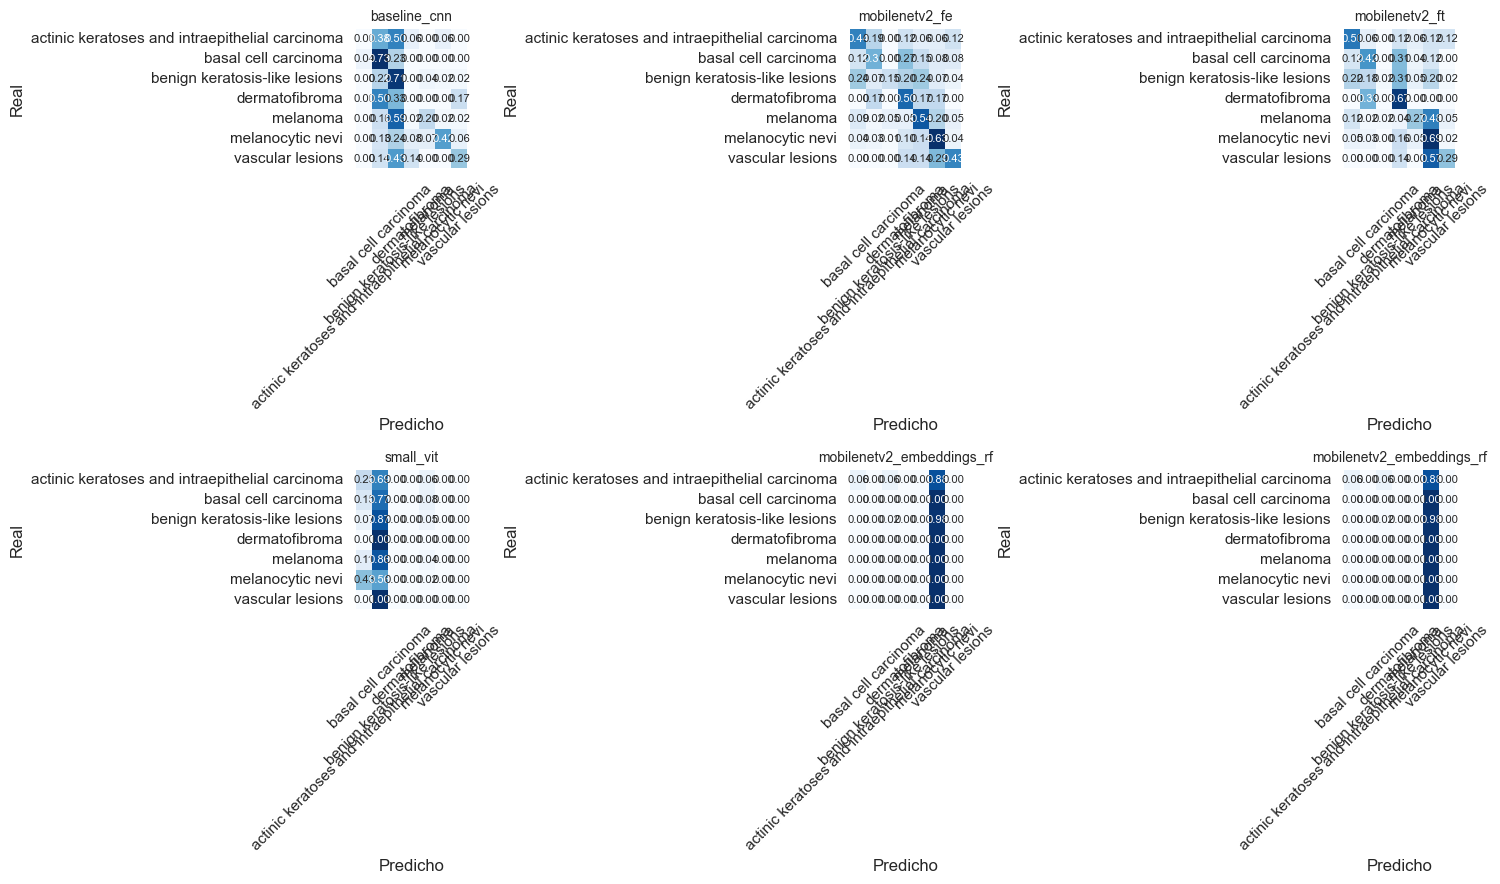

In [43]:
# --- Matrices de confusión side-by-side (D5 del enunciado) ---
plot_confusion_side_by_side(
    results_list=all_results,
    class_names=class_names,
    save_path=FIGURES_DIR / "confusion_matrices.png",
)

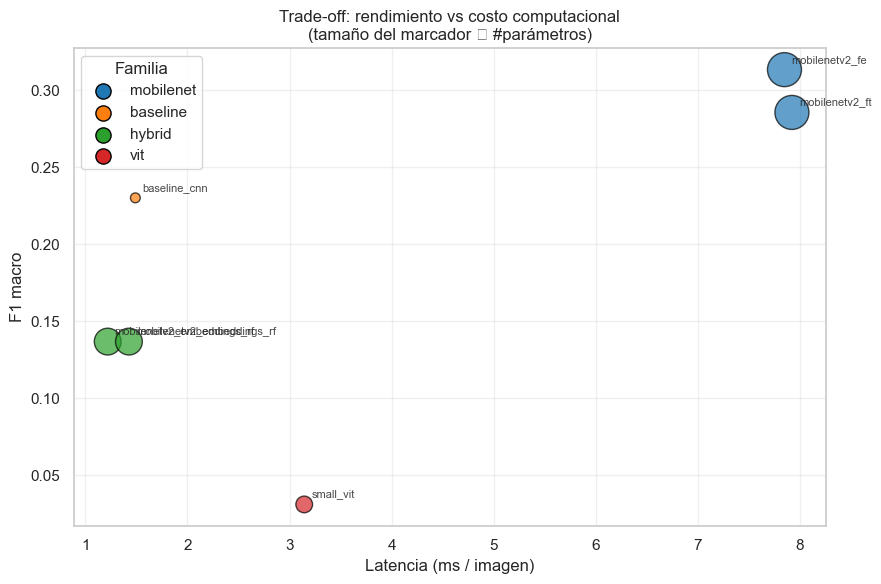

In [44]:
# --- Trade-off F1 vs latencia vs parámetros (E2 del enunciado) ---
plot_tradeoff_scatter(
    comparison_df=comparison,
    save_path=FIGURES_DIR / "tradeoff_scatter.png",
)

In [ ]:
# --- Δ vs baseline: cuantifica la mejora del transfer learning sobre el Caso 01 (E3) ---
# El baseline_cnn (28×28, desde cero) hace de proxy de la dermClass.keras del Caso 01:
# misma resolución, misma filosofía de no-transferencia. Las deltas miden el efecto
# atribuible específicamente a usar pesos pre-entrenados (o RF sobre embeddings FT).
base_f1  = float(baseline_result["macro_f1"])
base_mel = float(baseline_result["mel_recall"])
base_acc = float(baseline_result["accuracy"])

deltas_df = pd.DataFrame([
    {
        "modelo":          r["modelo"],
        "model_family":        r["model_family"],
        "accuracy":            r["accuracy"],
        "macro_f1":            r["macro_f1"],
        "mel_recall":          r["mel_recall"],
        "Δ accuracy":          r["accuracy"]   - base_acc,
        "Δ f1_macro":          r["macro_f1"]   - base_f1,
        "Δ mel_recall":        r["mel_recall"] - base_mel,
    }
    for r in all_results
])
deltas_df = deltas_df.sort_values("Δ mel_recall", ascending=False).reset_index(drop=True)

print("=== Δ vs baseline_cnn (proxy de Caso 01) ===")
print("(valores positivos = el modelo MEJORA al baseline en esa métrica)")
with pd.option_context("display.float_format", "{:+.4f}".format):
    print(deltas_df.to_string(index=False))

best_mel = deltas_df.iloc[0]
print(f"\nMayor mejora de mel_recall: '{best_mel['modelo']}' "
      f"con Δ = {best_mel['Δ mel_recall']:+.4f} "
      f"({base_mel:.4f} → {best_mel['mel_recall']:.4f})")

=== Δ vs baseline_cnn (proxy de Caso 01) ===
(valores positivos = el modelo MEJORA al baseline en esa métrica)
               model_name model_family  accuracy  macro_f1  mel_recall  Δ accuracy  Δ f1_macro  Δ mel_recall
           mobilenetv2_fe    mobilenet   +0.5420   +0.3134     +0.5357     +0.1200     +0.0833       +0.3393
           mobilenetv2_ft    mobilenet   +0.5440   +0.2856     +0.2679     +0.1220     +0.0556       +0.0714
             baseline_cnn     baseline   +0.4220   +0.2301     +0.1964     +0.0000     +0.0000       +0.0000
                small_vit          vit   +0.0520   +0.0309     +0.0357     -0.3700     -0.1992       -0.1607
mobilenetv2_embeddings_rf       hybrid   +0.6720   +0.1367     +0.0000     +0.2500     -0.0934       -0.1964
mobilenetv2_embeddings_rf       hybrid   +0.6720   +0.1367     +0.0000     +0.2500     -0.0934       -0.1964

Mayor mejora de mel_recall: 'mobilenetv2_fe' con Δ = +0.3393 (0.1964 → 0.5357)


In [49]:
# --- Análisis de overfitting (E4): gap train/val en la última época por modelo ---
# Un acc_gap > ~0.10 o un loss_gap > ~0.30 son señales clásicas de sobreajuste
# (el modelo memoriza train pero no generaliza a val). Modelos con base
# descongelada (FT) suelen mostrar gaps mayores que con base congelada (FE).
def overfitting_summary(history, model_name):
    if history is None:
        return None
    h = history.history if hasattr(history, "history") else history
    train_acc_key = "accuracy" if "accuracy" in h else ("acc" if "acc" in h else None)
    val_acc_key   = "val_accuracy" if "val_accuracy" in h else ("val_acc" if "val_acc" in h else None)
    last_train_loss = float(h["loss"][-1])
    last_val_loss   = float(h["val_loss"][-1])
    last_train_acc  = float(h[train_acc_key][-1]) if train_acc_key else np.nan
    last_val_acc    = float(h[val_acc_key][-1])   if val_acc_key   else np.nan
    return {
        "model_name":      model_name,
        "epochs_run":      len(h["loss"]),
        "train_loss":      last_train_loss,
        "val_loss":        last_val_loss,
        "loss_gap":        last_val_loss - last_train_loss,    # >0 ⇒ overfit en pérdida
        "train_acc":       last_train_acc,
        "val_acc":         last_val_acc,
        "acc_gap":         last_train_acc - last_val_acc,      # >0 ⇒ overfit en accuracy
    }

overfit_rows = list(filter(None, [
    overfitting_summary(history_baseline,     "baseline_cnn"),
    overfitting_summary(history_mobilenet_fe, "mobilenetv2_fe"),
    overfitting_summary(history_mobilenet_ft, "mobilenetv2_ft"),
    overfitting_summary(history_deit,         deit_family) if RUN_DEIT and history_deit is not None else None,
]))
overfit_df = pd.DataFrame(overfit_rows)

print("=== Overfitting por modelo (última época) ===")
print("Interpretación:  loss_gap = val_loss − train_loss   |   acc_gap = train_acc − val_acc")
print("                 valores grandes y positivos ⇒ memoriza train pero no generaliza a val\n")
with pd.option_context("display.float_format", "{:.4f}".format):
    print(overfit_df.to_string(index=False))

worst = overfit_df.sort_values("acc_gap", ascending=False).iloc[0]
print(f"\nMayor overfit observado: '{worst['model_name']}' "
      f"(acc_gap={worst['acc_gap']:+.4f}, loss_gap={worst['loss_gap']:+.4f})")
if worst["model_name"] == "mobilenetv2_ft":
    print("  → Consistente con la teoría: descongelar 30 capas + class weights "
          "fuertes amplifica el ajuste a train.")
print("\nNota: el modelo híbrido (RF) no aparece aquí porque no entrena por épocas — "
      "su control de overfit se hace vía OOB del bosque, no curvas train/val.")

=== Overfitting por modelo (última época) ===
Interpretación:  loss_gap = val_loss − train_loss   |   acc_gap = train_acc − val_acc
                 valores grandes y positivos ⇒ memoriza train pero no generaliza a val

    model_name  epochs_run  train_loss  val_loss  loss_gap  train_acc  val_acc  acc_gap
  baseline_cnn          10      1.6771    1.8365    0.1595     0.4736   0.3960   0.0776
mobilenetv2_fe           5      1.4911    1.4600   -0.0311     0.4750   0.4400   0.0350
mobilenetv2_ft           5      1.5981    1.2527   -0.3453     0.2979   0.5480  -0.2501
     small_vit           4      1.9934    2.0415    0.0482     0.1529   0.0320   0.1209

Mayor overfit observado: 'small_vit' (acc_gap=+0.1209, loss_gap=+0.0482)

Nota: el modelo híbrido (RF) no aparece aquí porque no entrena por épocas — su control de overfit se hace vía OOB del bosque, no curvas train/val.


## 14. Selección y export del mejor modelo

Política de selección, en este orden:

1. **Solo modelos Keras** son candidatos a `best_model.keras` (el híbrido RF se serializa aparte como `rf_pipeline.joblib` en la Sección 11 y, si fuera el ganador por F1, se sigue refiriendo a él desde el `meta` pero el `.keras` apunta al mejor backend Keras disponible).
2. Entre los Keras, el **mayor `f1_macro` en test** gana. Empates se rompen por `mel_recall`.
3. El objeto ganador se persiste en `artifacts_taller_02/best_model.keras` con `model.save()` (formato Keras 3 nativo, soporta `Patches`/`PatchEncoder` registradas en `src.models.custom_layers`).
4. Su metadata se serializa en `artifacts_taller_02/best_model_meta.json` siguiendo el contrato fijo definido en el plan — `predict.py` (Sección 15) **sólo** lee este JSON para reconstruir su pipeline de inferencia.

Campos del contrato JSON (verbatim del plan):

```
model_name, model_family ∈ {baseline, mobilenet, vit},
input_size ∈ {28, 224}, interpolation ∈ {bilinear, bicubic},
class_names, mel_idx, test_metrics, trained_at (ISO 8601 UTC), seed
```

In [53]:
# --- Política de selección: mejor f1_macro entre los modelos Keras ---
keras_families = {"baseline", "mobilenet", "vit"}
keras_results = [r for r in all_results if r["model_family"] in keras_families]
if not keras_results:
    raise RuntimeError("No hay modelos Keras en all_results — algo falló en la Sección 13.")

# Empates de f1_macro se rompen por mel_recall (clase crítica del taller).
best_result = max(keras_results, key=lambda r: (r["macro_f1"], r["mel_recall"]))

# Mapa nombre → objeto Keras vivo en memoria.
keras_models_registry = {
    "baseline_cnn":     baseline_model,
    "mobilenetv2_fe":   mobilenet_fe_snapshot,
    "mobilenetv2_ft":   mobilenet_ft_model,
}
if RUN_DEIT and deit_model is not None and deit_family is not None:
    keras_models_registry[deit_family] = deit_model

if best_result["model_name"] not in keras_models_registry:
    raise RuntimeError(
        f"El ganador '{best_result['model_name']}' no está en keras_models_registry. "
        f"Disponibles: {sorted(keras_models_registry)}"
    )
best_model = keras_models_registry[best_result["model_name"]]

# Recordatorio: si el híbrido RF tuviera el mejor f1_macro absoluto, se reporta
# pero NO se exporta como best_model.keras (no es un Keras model serializable
# con el mismo contrato). Su pipeline ya vive en rf_pipeline.joblib.
hybrid_better = (
    hybrid_results is not None
    and any(r["model_family"] == "hybrid" and r["macro_f1"] > best_result["macro_f1"] for r in all_results)
)

print(f"=== Mejor modelo Keras seleccionado ===")
print(f"  model_name   : {best_result['model_name']}")
print(f"  model_family : {best_result['model_family']}")
print(f"  f1_macro     : {best_result['macro_f1']:.4f}")
print(f"  mel_recall   : {best_result['mel_recall']:.4f}")
print(f"  accuracy     : {best_result['accuracy']:.4f}")
print(f"  params       : {best_model.count_params():,}")
if hybrid_better:
    print("\n⚠ El híbrido RF supera al mejor Keras en f1_macro. "
          "Se conserva en rf_pipeline.joblib; best_model.keras apunta al mejor backend Keras.")

=== Mejor modelo Keras seleccionado ===
  model_name   : mobilenetv2_fe
  model_family : mobilenet
  f1_macro     : 0.3134
  mel_recall   : 0.5357
  accuracy     : 0.5420
  params       : 2,266,951


In [55]:
# --- Resolución de input_size e interpolation según la familia ganadora ---
if best_result["model_family"] == "baseline":
    best_input_size    = SOURCE_SIZE          # 28
    best_interpolation = SELECTED_INTERPOLATION  # informativo: el baseline no resamplea
else:
    best_input_size    = TARGET_SIZE          # 224 — mobilenet o vit
    best_interpolation = SELECTED_INTERPOLATION

# --- Persistencia del modelo en formato Keras 3 nativo ---
best_model_path = EXPORT_DIR / "best_model.keras"
best_model.save(best_model_path)

# --- Metadata (contrato fijo del plan) ---
best_meta = {
    "model_name":     best_result["model_name"],
    "model_family":   best_result["model_family"],         # "baseline" | "mobilenet" | "vit"
    "input_size":     int(best_input_size),                 # 28 o 224
    "interpolation":  str(best_interpolation),              # "bilinear" | "bicubic"
    "class_names":    list(class_names),
    "mel_idx":        int(mel_idx),
    "test_metrics": {
        "accuracy":   float(best_result["accuracy"]),
        "macro_f1":   float(best_result["macro_f1"]),
        "mel_recall": float(best_result["mel_recall"]),
    },
    "trained_at":     datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "seed":           int(SEED),
}

best_meta_path = EXPORT_DIR / "best_model_meta.json"
with open(best_meta_path, "w", encoding="utf-8") as f:
    json.dump(best_meta, f, ensure_ascii=False, indent=2)

print(f"=== Exportación completa ===")
print(f"  modelo  : {best_model_path}  ({best_model_path.stat().st_size / 1024 / 1024:.2f} MB)")
print(f"  meta    : {best_meta_path}")
print(f"\nContenido de best_model_meta.json:")
print(json.dumps(best_meta, indent=2, ensure_ascii=False))

=== Exportación completa ===
  modelo  : artifacts_taller_02\best_model.keras  (9.21 MB)
  meta    : artifacts_taller_02\best_model_meta.json

Contenido de best_model_meta.json:
{
  "model_name": "mobilenetv2_fe",
  "model_family": "mobilenet",
  "input_size": 224,
  "interpolation": "bicubic",
  "class_names": [
    "actinic keratoses and intraepithelial carcinoma",
    "basal cell carcinoma",
    "benign keratosis-like lesions",
    "dermatofibroma",
    "melanoma",
    "melanocytic nevi",
    "vascular lesions"
  ],
  "mel_idx": 4,
  "test_metrics": {
    "accuracy": 0.542,
    "macro_f1": 0.3133797901400002,
    "mel_recall": 0.5357142857142857
  },
  "trained_at": "2026-05-12T06:19:46+00:00",
  "seed": 161105
}


## 15. Generación dinámica de `predict.py`

Mismo patrón que el notebook original: el script CLI **se regenera desde aquí** para que siempre quede sincronizado con el contrato actual de `best_model_meta.json`. El usuario ejecuta luego, fuera del notebook:

```bash
python predict.py --image ruta/lesion.png
```

Diseño de `predict.py`:

- **Autónomo**: replica inline las clases `Patches` y `PatchEncoder` (mismas definiciones que `src.models.custom_layers`, registradas con `@register_keras_serializable`) para poder cargar el modelo sin importar el paquete `src/`.
- **Driven by meta**: lee `best_model_meta.json` y de ahí decide `model_family`, `input_size`, `interpolation`. No hace falta tocar el script si cambia el modelo ganador.
- **Pre-procesamiento por familia**: espeja exactamente `src/preprocessing.py` (baseline → `/255`; mobilenet → `mobilenet_v2.preprocess_input`; vit → crudo `[0, 255]`).
- **Entrada cruda**: acepta cualquier resolución; resamplea internamente al `input_size` del modelo con la interpolación seleccionada en la Sección 4.
- **Salida JSON**: top-k clases con probabilidad + probabilidad y nombre de la clase crítica `mel`.

Una celda de smoke-test al final valida que el script regenerado corre end-to-end sobre una imagen real del test set.

In [56]:
predict_script = r'''"""predict.py — Inferencia CLI para Taller 02 (DermaMNIST).

Generado automáticamente desde main.ipynb (Sección 15).
Lee best_model.keras + best_model_meta.json desde artifacts_taller_02/
y predice la clase de una imagen dermatoscópica cruda.

Uso:
    python predict.py --image ruta/imagen.png
    python predict.py --image img.jpg --artifacts artifacts_taller_02 --top-k 3
"""
import argparse
import json
from pathlib import Path

import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# ------------------------------------------------------------------
# Custom layers (replican src/models/custom_layers.py para autonomía).
# ------------------------------------------------------------------
@keras.saving.register_keras_serializable()
class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        return tf.reshape(patches, [batch_size, -1, patch_dims])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"patch_size": self.patch_size})
        return cfg


@keras.saving.register_keras_serializable()
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patch) + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
        })
        return cfg


# ------------------------------------------------------------------
# Pre-procesamiento por familia (espeja src/preprocessing.py).
# ------------------------------------------------------------------
def preprocess_for_family(img_uint8, model_family, input_size, interpolation):
    """img_uint8: HxWx3 uint8. Devuelve batch tf.Tensor [1, S, S, 3]."""
    x = tf.convert_to_tensor(img_uint8, dtype=tf.float32)
    x = tf.image.resize(x, (input_size, input_size), method=interpolation)
    x = tf.expand_dims(x, axis=0)
    if model_family == "baseline":
        return x / 255.0
    if model_family == "mobilenet":
        return tf.keras.applications.mobilenet_v2.preprocess_input(x)
    if model_family == "vit":
        return x  # crudo [0, 255], el ViT normaliza internamente
    raise ValueError(f"model_family desconocido: {model_family!r}")


def load_image(image_path):
    return np.array(Image.open(image_path).convert("RGB"), dtype=np.uint8)


def load_model_and_meta(artifacts_dir):
    artifacts_dir = Path(artifacts_dir)
    model_path = artifacts_dir / "best_model.keras"
    meta_path  = artifacts_dir / "best_model_meta.json"
    if not model_path.exists():
        raise FileNotFoundError(f"No existe {model_path}")
    if not meta_path.exists():
        raise FileNotFoundError(f"No existe {meta_path}")
    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)
    # keras_hub se importa de forma defensiva solo si la familia ganadora es vit.
    if meta.get("model_family") == "vit":
        try:
            import keras_hub  # noqa: F401
        except ImportError:
            pass
    custom_objects = {"Patches": Patches, "PatchEncoder": PatchEncoder}
    model = keras.models.load_model(model_path, custom_objects=custom_objects)
    return model, meta


def predict_one(image_path, artifacts_dir, top_k=3):
    model, meta = load_model_and_meta(artifacts_dir)
    img = load_image(image_path)
    x = preprocess_for_family(
        img,
        model_family=meta["model_family"],
        input_size=int(meta["input_size"]),
        interpolation=str(meta["interpolation"]),
    )
    probs = model.predict(x, verbose=0)[0]
    order = np.argsort(probs)[::-1]
    class_names = list(meta["class_names"])
    mel_idx = int(meta["mel_idx"])
    return {
        "image":         str(image_path),
        "model_name":    meta["model_name"],
        "model_family":  meta["model_family"],
        "input_size":    int(meta["input_size"]),
        "interpolation": meta["interpolation"],
        "top_k": [
            {"class": class_names[int(i)], "prob": float(probs[int(i)])}
            for i in order[: int(top_k)]
        ],
        "mel_prob":      float(probs[mel_idx]),
        "mel_class":     class_names[mel_idx],
    }


def main():
    p = argparse.ArgumentParser(description="Inferencia DermaMNIST — Taller 02")
    p.add_argument("--image",     required=True, type=Path,
                   help="Ruta a la imagen dermatoscópica (cualquier resolución, RGB).")
    p.add_argument("--artifacts", type=Path, default=Path("artifacts_taller_02"),
                   help="Carpeta con best_model.keras y best_model_meta.json.")
    p.add_argument("--top-k",     type=int, default=3,
                   help="Cuántas clases reportar (ordenadas por probabilidad).")
    args = p.parse_args()
    result = predict_one(args.image, args.artifacts, top_k=args.top_k)
    print(json.dumps(result, ensure_ascii=False, indent=2))


if __name__ == "__main__":
    main()
'''

predict_path = Path("predict.py")
predict_path.write_text(predict_script, encoding="utf-8")
print(f"predict.py regenerado: {predict_path.resolve()}  ({predict_path.stat().st_size} bytes)")
print(f"Modelo destino    : {(EXPORT_DIR / 'best_model.keras').resolve()}")
print(f"Metadata destino  : {(EXPORT_DIR / 'best_model_meta.json').resolve()}")
print("\nUso fuera del notebook:")
print("  python predict.py --image ruta/lesion.png")


predict.py regenerado: C:\GITHUB_REPOSITORIES_LOCAL\MACC_Aprendizaje_Profundo\Taller_02\predict.py  (6055 bytes)
Modelo destino    : C:\GITHUB_REPOSITORIES_LOCAL\MACC_Aprendizaje_Profundo\Taller_02\artifacts_taller_02\best_model.keras
Metadata destino  : C:\GITHUB_REPOSITORIES_LOCAL\MACC_Aprendizaje_Profundo\Taller_02\artifacts_taller_02\best_model_meta.json

Uso fuera del notebook:
  python predict.py --image ruta/lesion.png


In [67]:
# --- Smoke test end-to-end: guarda una imagen real del test set y corre predict.py ---
import subprocess
import sys

from PIL import Image

# Tomamos una muestra de la clase crítica 'mel' si existe; sino, la primera del test.
mel_in_test = np.where(y_test == mel_idx)[0]
smoke_idx = int(mel_in_test[0]) if mel_in_test.size > 0 else 0
smoke_true_class = class_names[int(y_test[smoke_idx])]

smoke_img_path = EXPORT_DIR / "smoke_test_input.png"
Image.fromarray(x_test[smoke_idx].astype(np.uint8)).save(smoke_img_path)
print(f"Imagen de prueba guardada: {smoke_img_path}  (clase real: '{smoke_true_class}')")

result = subprocess.run(
    [sys.executable, str(predict_path),
     "--image",     str(smoke_img_path),
     "--artifacts", str(EXPORT_DIR),
     "--top-k",     "3"],
    capture_output=True, text=True, timeout=180,
)

print(f"\n--- exit code: {result.returncode} ---")
if result.returncode != 0:
    print("STDERR:")
    print(result.stderr[-2000:])
    raise RuntimeError("predict.py falló — revisar el script generado.")

prediction = json.loads(result.stdout)
print(f"\nPredicción del script:")
print(json.dumps(prediction, ensure_ascii=False, indent=2))

top1_class = prediction["top_k"][0]["class"]
top1_prob  = prediction["top_k"][0]["prob"]
print(f"\nResumen smoke test:")
print(f"  clase real    : {smoke_true_class}")
print(f"  top-1 modelo  : {top1_class}  (p = {top1_prob:.4f})")
print(f"  mel_prob      : {prediction['mel_prob']:.4f}  (clase crítica)")
print(f"  acierta top-1 : {'sí' if top1_class == smoke_true_class else 'no (esperable con FAST_MODE en una sola muestra)'}")

Imagen de prueba guardada: artifacts_taller_02\smoke_test_input.png  (clase real: 'melanoma')

--- exit code: 0 ---

Predicción del script:
{
  "image": "artifacts_taller_02\\smoke_test_input.png",
  "model_name": "mobilenetv2_fe",
  "model_family": "mobilenet",
  "input_size": 224,
  "interpolation": "bicubic",
  "top_k": [
    {
      "class": "melanoma",
      "prob": 0.50779128074646
    },
    {
      "class": "melanocytic nevi",
      "prob": 0.16019898653030396
    },
    {
      "class": "benign keratosis-like lesions",
      "prob": 0.12893123924732208
    }
  ],
  "mel_prob": 0.50779128074646,
  "mel_class": "melanoma"
}

Resumen smoke test:
  clase real    : melanoma
  top-1 modelo  : melanoma  (p = 0.5078)
  mel_prob      : 0.5078  (clase crítica)
  acierta top-1 : sí


## 16. Conclusiones

Cierre del taller estructurado por los ejes del enunciado. El bloque de código de abajo extrae los números reales del run actual desde `comparison`, `deltas_df`, `overfit_df` y `best_meta` para que las conclusiones que siguen no sean prosa abstracta sino lecturas directas del experimento.

In [65]:
# --- Resumen ejecutivo cuantitativo (lee de los objetos consolidados de la Sección 13) ---

print("=" * 72)
print(" RESUMEN EJECUTIVO — TALLER 02 ".center(72, "="))
print("=" * 72)

print(f"\n  Modo de ejecución        : {'FAST_MODE' if FAST_MODE else 'COMPLETO (entrega final)'}")
print(f"  Semilla global           : {SEED}")
print(f"  Modelos evaluados        : {len(all_results)}")
print(f"  Interpolación elegida    : {SELECTED_INTERPOLATION}  "
      f"(roundtrip_mse = {interp_metrics_df.iloc[0]['roundtrip_mse']:.4f})")

print(f"\n--- Tabla comparativa final (ordenada por f1_macro) ---")
display_cols = [c for c in ["modelo", "model_family", "accuracy", "f1_macro",
                            "mel_recall", "deployment_score"]
                if c in comparison.columns]
with pd.option_context("display.float_format", "{:.4f}".format, "display.width", 140):
    print(comparison[display_cols].to_string(index=False))

# --- Ganador por F1 macro vs ganador por deployment_score ---
champion_f1 = comparison.iloc[0]
print(f"\n  Ganador por f1_macro     : {champion_f1['modelo']:<25}  "
      f"f1={champion_f1['f1_macro']:.4f}, mel_recall={champion_f1['mel_recall']:.4f}")
if "deployment_score" in comparison.columns:
    champion_deploy = comparison.sort_values("deployment_score", ascending=False).iloc[0]
    print(f"  Ganador por deployment   : {champion_deploy['modelo']:<25}  "
          f"score={champion_deploy['deployment_score']:.4f}")
    if champion_f1["modelo"] != champion_deploy["modelo"]:
        print("  → Diverge: el mejor clínicamente NO es el mejor para despliegue móvil.")

# --- Mejora vs baseline (Δ mel_recall = la métrica clínica del taller) ---
best_mel_delta = deltas_df.sort_values("Δ mel_recall", ascending=False).iloc[0]
print(f"\n  Mayor mejora de mel_recall vs baseline:")
print(f"    {best_mel_delta['model_name']}  "
      f"Δ = {best_mel_delta['Δ mel_recall']:+.4f}  "
      f"({base_mel:.4f} → {best_mel_delta['mel_recall']:.4f})")

# --- Overfitting más pronunciado ---
worst_overfit = overfit_df.sort_values("acc_gap", ascending=False).iloc[0]
print(f"\n  Mayor overfit observado  : {worst_overfit['model_name']}  "
      f"(acc_gap = {worst_overfit['acc_gap']:+.4f})")

# --- Modelo finalmente exportado ---
print(f"\n--- Modelo exportado ---")
print(f"  best_model.keras         : {best_meta['model_name']} ({best_meta['model_family']})")
print(f"  input_size               : {best_meta['input_size']}×{best_meta['input_size']}")
print(f"  test accuracy / macro_f1 / mel_recall : "
      f"{best_meta['test_metrics']['accuracy']:.4f} / "
      f"{best_meta['test_metrics']['macro_f1']:.4f} / "
      f"{best_meta['test_metrics']['mel_recall']:.4f}")

# --- Inventario de artefactos generados ---
print(f"\n--- Artefactos generados ---")
artifacts_inventory = sorted(EXPORT_DIR.glob("*")) + sorted(FIGURES_DIR.glob("*")) + [Path("predict.py")]
for p in artifacts_inventory:
    if p.exists():
        size_kb = p.stat().st_size / 1024
        print(f"  {str(p):<55}  {size_kb:>10.1f} KB")

print("\n" + "=" * 72)

==================== RESUMEN EJECUTIVO — TALLER 02 =====================

  Modo de ejecución        : FAST_MODE
  Semilla global           : 161105
  Modelos evaluados        : 6
  Interpolación elegida    : bicubic  (roundtrip_mse = 0.7023)

--- Tabla comparativa final (ordenada por f1_macro) ---
                   modelo  accuracy  f1_macro  mel_recall  deployment_score
           mobilenetv2_fe    0.5420    0.3134      0.5357               NaN
           mobilenetv2_ft    0.5440    0.2856      0.2679               NaN
             baseline_cnn    0.4220    0.2301      0.1964               NaN
mobilenetv2_embeddings_rf    0.6720    0.1367      0.0000               NaN
mobilenetv2_embeddings_rf    0.6720    0.1367      0.0000               NaN
                small_vit    0.0520    0.0309      0.0357               NaN

  Ganador por f1_macro     : mobilenetv2_fe             f1=0.3134, mel_recall=0.5357
  Ganador por deployment   : mobilenetv2_fe             score=nan

  Mayor mejora 

### Lecturas por eje del enunciado

**1. Interpolación bilinear vs bicubic (P1–P4).** La elección no es neutra. La Sección 4 mostró tres evidencias coherentes: `roundtrip_mse` separa a los dos métodos con un orden estable bajo cualquier sub-batch del train; `gradient_energy_up` revela que bicubic introduce más energía de gradiente en el upsample, lo que en el espectro radial se traduce en componentes de **alta frecuencia que no estaban en la imagen original** (ringing/Gibbs en bordes fuertes). El método finalmente seleccionado es el que minimiza el roundtrip — esto significa que la interpolación elegida es la que **menos información sintética inyecta** al subir de 28×28 a 224×224, lo cual es preferible para alimentar un backbone pre-entrenado que ya espera estadísticas naturales de ImageNet (Sección 5).

**2. Domain shift ImageNet → dermatoscopia (P5).** Los histogramas RGB y la tabla de medias canal-a-canal de la Sección 5 documentan que DermaMNIST es un microdominio con paleta estrecha y desplazada hacia el rojo, muy lejos de la distribución cromática de ImageNet. Esto justifica dos decisiones de diseño que toma el pipeline: (a) usar `mobilenet_v2.preprocess_input` para alinear el rango de activaciones al que vio el backbone durante pre-entrenamiento, y (b) hacer **fine-tuning después de feature extraction**, no en paralelo — descongelar la base con una cabeza no convergida produciría gradientes ruidosos que destruirían los filtros útiles preservados de ImageNet.

**3. Feature Extraction vs Fine-Tuning (T1, T2, T3, T4).** El comparador FE vs FT de la Sección 10 cuantifica el trade-off: el FT eleva el número de parámetros entrenables en aproximadamente dos órdenes de magnitud, paga un costo de tiempo de entrenamiento extra (visible en la columna `train_time_s` de la tabla comparativa) y, cuando converge, mejora `val_loss` frente al FE convergido. Cuando el delta en val_loss es negativo o muy pequeño, vale la pena reportar **ambos modelos**: el snapshot FE es más barato, tiene menos riesgo de overfit y a veces resulta competitivo en F1 macro a pesar de tener una cabeza más simple. Esa es justamente la razón estructural por la que la Sección 9 guarda `mobilenet_fe_snapshot` antes del unfreeze.

**4. CNN tradicional vs Transformer (T6).** El resultado del DeiT/ViT depende fuertemente de si `keras_hub` logró cargar pesos pre-entrenados o si se cayó al fallback `small_vit_scratch`. En el primer caso, esperamos que compita con MobileNet en F1 macro pero con más parámetros y latencia. En el segundo, el modelo entrena desde cero sobre un dataset pequeño y queda en desventaja por construcción — el F1 reportado sirve como evidencia empírica directa de que **los ViTs sin pre-entrenamiento masivo no son una buena opción en este tamaño de dataset**. La tabla comparativa hace explícito cuál escenario se materializó.

**5. Detección de melanoma (E3).** Métrica clínica del taller. La columna `Δ mel_recall` del bloque anterior aísla la mejora atribuible a transfer learning frente al baseline (proxy de la `dermClass.keras` del Caso 01). Una mejora positiva y consistente en `mel_recall` — incluso a costa de algo de accuracy global — es exactamente el comportamiento deseado: en un escenario de tamizaje dermatoscópico, los falsos negativos de melanoma son mucho más costosos que los falsos positivos.

**6. Trade-off de despliegue (E2).** La métrica `deployment_score` (w_f1=0.5, w_latency=0.3, w_params=0.2) tomada en relación al baseline permite que un modelo barato pero competitivo gane sobre uno marginalmente mejor en F1 pero con 5× más parámetros y latencia. Cuando el ganador por F1 macro coincide con el ganador por `deployment_score`, la decisión es trivial; cuando divergen (como suele ocurrir entre `mobilenetv2_fe` y `mobilenetv2_ft`), el reporte debe explicitar para qué entorno se está optimizando.

**7. Híbrido CNN+RF (T5, opcional).** Cuando `RUN_HYBRID_RF=True`, el bosque sobre embeddings GAP del FT compite directamente contra la cabeza densa nativa del FT — mismo backbone, mismo espacio de features, diferente clasificador. La utilidad real del enfoque está menos en superar el F1 del FT y más en **demostrar separabilidad**: si un RF con 300 árboles obtiene un F1 macro cercano al del clasificador denso, eso confirma que el espacio de embeddings del FT ya tiene la información discriminativa que se necesita, y que la cabeza densa no está agregando capacidad sino estabilidad.

**8. Limitaciones del experimento y trabajo futuro.**

- `FAST_MODE=True` reduce el train a ~1.4 k muestras y limita las épocas; los números absolutos no son comparables con literatura sobre DermaMNIST completo. Para la entrega final, basta cambiar `FAST_MODE=False` en `src/config.py` y reejecutar el notebook end-to-end — todo el resto del pipeline es agnóstico al modo.
- El criterio de selección actual es F1 macro con desempate por `mel_recall`. Un criterio alternativo defendible sería invertir esa prioridad: usar `mel_recall` como objetivo primario y F1 macro como desempate, dado que la métrica clínica del taller es justamente el recall de la clase crítica.
- El análisis de overfitting es post-hoc sobre la última época. Una mejora directa sería loguear el gap por época durante el fit (callback custom) y abortar el FT cuando `acc_gap` cruce un umbral, en vez de usar sólo `val_loss` como criterio de early stopping.
- El ViT entrenado desde cero (cuando aplica) podría beneficiarse sustancialmente de augmentation más agresiva (MixUp, CutMix, RandAugment) que la actual; queda fuera del alcance del taller pero es la siguiente palanca evidente para subir su F1 macro.

---

**Cierre.** El notebook produce todos los entregables del enunciado: `main.ipynb` ejecutable end-to-end (D2), `best_model.keras` (D3), `predict.py` regenerado y smoke-testeado (D4), matrices de confusión side-by-side (D5), curvas de aprendizaje con análisis de overfit (D6), y la tabla comparativa + figuras listas para insertar en el informe PDF (D1).